# Time-Series Foundation Models

## 1. Research Objective

Evaluate whether time-series foundation models can be used responsibly on the same Bitcoin daily Close forecasting task as the rest of this project. This notebook deliberately separates compatibility checks, runnable forecasts, diagnostics, and non-runnable implementation plans so that no model result is invented.

Scope:
- Dataset: Bitcoin daily Close series.
- Split: same 80/20 chronological split used elsewhere in the project.
- Primary protocol: rolling one-step forecasting when the model interface and runtime make it practical.
- Foundation models considered: Chronos, TimesFM, and Moirai.


## 2. Environment and Compatibility Check

In [1]:
from pathlib import Path
import importlib.util
import platform
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_bitcoin_data
from src.preprocessing import prepare_daily_bitcoin_data
from src.metrics import mae, rmse, mape, smape

pd.set_option("display.float_format", "{:.6f}".format)
warnings.filterwarnings("ignore")


In [2]:
def package_available(module_name):
    return importlib.util.find_spec(module_name) is not None


try:
    import torch
except Exception:
    torch = None

try:
    import psutil
except Exception:
    psutil = None

total_ram_gb = psutil.virtual_memory().total / 1024**3 if psutil else np.nan
available_ram_gb = psutil.virtual_memory().available / 1024**3 if psutil else np.nan

environment_summary = pd.DataFrame(
    [
        {"Item": "Python version", "Value": platform.python_version()},
        {"Item": "Platform", "Value": platform.platform()},
        {"Item": "PyTorch version", "Value": getattr(torch, "__version__", "Not installed")},
        {"Item": "CUDA available", "Value": bool(torch.cuda.is_available()) if torch else False},
        {"Item": "Total RAM GB", "Value": round(total_ram_gb, 2) if psutil else "psutil not installed"},
        {"Item": "Available RAM GB", "Value": round(available_ram_gb, 2) if psutil else "psutil not installed"},
        {"Item": "chronos package available", "Value": package_available("chronos")},
        {"Item": "timesfm package available", "Value": package_available("timesfm")},
        {"Item": "uni2ts package available", "Value": package_available("uni2ts")},
    ]
)
environment_summary


,Item,Value
0,Python version,3.13.2
1,Platform,Windows-11-10.0.26100-SP0
2,PyTorch version,2.12.1+cpu
3,CUDA available,False
4,Total RAM GB,15.340000
5,Available RAM GB,4.870000
6,chronos package available,True
7,timesfm package available,True
8,uni2ts package available,False


In [3]:
compatibility_table = pd.DataFrame(
    [
        {
            "Model": "Chronos",
            "Source": "amazon-science/chronos-forecasting",
            "Supported Python": ">=3.10",
            "Required Packages": "chronos-forecasting, torch>=2.2,<3, transformers>=4.41,<6, accelerate>=1.1,<2",
            "Smallest Suitable Model": "amazon/chronos-bolt-tiny or amazon/chronos-t5-tiny",
            "Model Size": "9M parameters for Chronos-Bolt tiny; 8M for Chronos T5 tiny",
            "Expected RAM": "Small model may be CPU-feasible, but model download plus inference needs several GB free RAM",
            "CPU Feasibility": "Potentially practical for tiny/mini models, not practical with very low available RAM",
            "Local Execution Practical Now": package_available("chronos") and available_ram_gb >= 4,
            "Current Blocker": "Package not installed or insufficient free RAM",
        },
        {
            "Model": "TimesFM",
            "Source": "google-research/timesfm",
            "Supported Python": ">=3.10",
            "Required Packages": "timesfm[torch], torch>=2.0.0, huggingface_hub, safetensors",
            "Smallest Suitable Model": "google/timesfm-2.5-200m-pytorch",
            "Model Size": "200M parameters",
            "Expected RAM": "Likely several GB free RAM for weights and inference buffers",
            "CPU Feasibility": "Possible but expected to be slow; less practical than Chronos tiny",
            "Local Execution Practical Now": package_available("timesfm") and available_ram_gb >= 6,
            "Current Blocker": "Package not installed; model is larger than Chronos tiny",
        },
        {
            "Model": "Moirai",
            "Source": "SalesforceAIResearch/uni2ts",
            "Supported Python": ">=3.10 in project metadata, but dependencies pin torch>=2.1,<2.5 and numpy~=1.26",
            "Required Packages": "uni2ts, torch>=2.1,<2.5, lightning>=2.0, gluonts~=0.14.3, datasets~=2.17.1",
            "Smallest Suitable Model": "moirai small variants, if compatible environment is created",
            "Model Size": "Varies by checkpoint; not selected for current environment",
            "Expected RAM": "Several GB free RAM; dependency stack is heavier than Chronos",
            "CPU Feasibility": "Research workflow is possible but not practical in current Python 3.13 / Torch 2.12.1 environment",
            "Local Execution Practical Now": package_available("uni2ts") and torch is not None and getattr(torch, "__version__", "0") < "2.5",
            "Current Blocker": "Current torch 2.12.1 violates uni2ts torch<2.5 requirement; package not installed",
        },
    ]
)
compatibility_table


,Model,Source,Supported Python,Required Packages,Smallest Suitable Model,Model Size,Expected RAM,CPU Feasibility,Local Execution Practical Now,Current Blocker
0,Chronos,amazon-science/chronos-forecasting,>=3.10,"chronos-forecasting, torch>=2.2,<3, transforme...",amazon/chronos-bolt-tiny or amazon/chronos-t5-...,9M parameters for Chronos-Bolt tiny; 8M for Ch...,"Small model may be CPU-feasible, but model dow...","Potentially practical for tiny/mini models, no...",True,Package not installed or insufficient free RAM
1,TimesFM,google-research/timesfm,>=3.10,"timesfm[torch], torch>=2.0.0, huggingface_hub,...",google/timesfm-2.5-200m-pytorch,200M parameters,Likely several GB free RAM for weights and inf...,Possible but expected to be slow; less practic...,False,Package not installed; model is larger than Ch...
2,Moirai,SalesforceAIResearch/uni2ts,">=3.10 in project metadata, but dependencies p...","uni2ts, torch>=2.1,<2.5, lightning>=2.0, gluon...","moirai small variants, if compatible environme...",Varies by checkpoint; not selected for current...,Several GB free RAM; dependency stack is heavi...,Research workflow is possible but not practica...,False,Current torch 2.12.1 violates uni2ts torch<2.5...


Compatibility sources used for the table above:
- Chronos official repository metadata: `requires-python >=3.10`, `torch>=2.2,<3`, model sizes including Chronos-Bolt tiny at 9M parameters.
- TimesFM official repository metadata: `requires-python >=3.10`, `timesfm[torch]`, `torch>=2.0.0`, 200M PyTorch example.
- Moirai / Uni2TS official repository metadata: `requires-python >=3.10`, but dependency pins include `torch>=2.1,<2.5` and `numpy~=1.26.0`, which are not compatible with this project's current Torch 2.12.1 environment.

The notebook does not install packages. It only runs a foundation model if the package is already available and the environment passes basic feasibility checks.


## 3. Load Dataset

In [4]:
data_path = PROJECT_ROOT / "data" / "bitcoin" / "btcusd_1-min_data.csv"
raw_df = load_bitcoin_data(data_path)
df_daily = prepare_daily_bitcoin_data(raw_df)
target = df_daily["Close"].asfreq("D").dropna().rename("Close")

dataset_summary = pd.DataFrame(
    [
        {"Item": "Full series length", "Value": len(target)},
        {"Item": "Start date", "Value": target.index.min()},
        {"Item": "End date", "Value": target.index.max()},
        {"Item": "Index sorted", "Value": target.index.is_monotonic_increasing},
        {"Item": "Duplicate timestamps", "Value": target.index.duplicated().any()},
        {"Item": "Missing values", "Value": int(target.isna().sum())},
    ]
)
dataset_summary


,Item,Value
0,Full series length,5302
1,Start date,2012-01-01 00:00:00+00:00
2,End date,2026-07-07 00:00:00+00:00
3,Index sorted,True
4,Duplicate timestamps,False
5,Missing values,0


## 4. Train-Test Split

In [5]:
split_idx = int(len(target) * 0.8)
train = target.iloc[:split_idx]
test = target.iloc[split_idx:]
y_test = test.copy()

split_summary = pd.DataFrame(
    [
        {"Item": "Train length", "Value": len(train)},
        {"Item": "Test length", "Value": len(test)},
        {"Item": "Train start", "Value": train.index.min()},
        {"Item": "Train end", "Value": train.index.max()},
        {"Item": "Test start", "Value": test.index.min()},
        {"Item": "Test end", "Value": test.index.max()},
        {"Item": "Train/test overlap", "Value": len(train.index.intersection(test.index)) > 0},
        {"Item": "Expected train end 2023-08-11", "Value": train.index.max() == pd.Timestamp("2023-08-11", tz="UTC")},
        {"Item": "Expected test start 2023-08-12", "Value": test.index.min() == pd.Timestamp("2023-08-12", tz="UTC")},
    ]
)
split_summary


,Item,Value
0,Train length,4241
1,Test length,1061
2,Train start,2012-01-01 00:00:00+00:00
3,Train end,2023-08-11 00:00:00+00:00
4,Test start,2023-08-12 00:00:00+00:00
5,Test end,2026-07-07 00:00:00+00:00
6,Train/test overlap,False
7,Expected train end 2023-08-11,True
8,Expected test start 2023-08-12,True


## 5. Forecasting Protocol

The main benchmark uses rolling one-step forecasting where technically supported:

1. At test date `t`, the model may use all observations strictly earlier than `t`.
2. It forecasts the next one day only.
3. After the true value for `t` is observed, that value may be appended to history for the next test step.
4. No forecast may use `actual[t]` or any later test value when predicting `t`.

For foundation models, this is often expensive because it may require repeated inference across the full test period. If a model can only be run practically as a short-horizon or recursive multi-step forecast, the protocol is labeled separately and excluded from direct rolling one-step comparisons.


In [6]:
def metric_row(model, forecast, actual=y_test, protocol="Rolling one-step", status="Run"):
    aligned = pd.concat([actual.rename("Actual"), forecast.rename("Forecast")], axis=1).dropna()
    if aligned.empty:
        return {
            "Model": model,
            "Protocol": protocol,
            "Status": status,
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE": np.nan,
            "sMAPE": np.nan,
        }
    return {
        "Model": model,
        "Protocol": protocol,
        "Status": status,
        "MAE": mae(aligned["Actual"], aligned["Forecast"]),
        "RMSE": rmse(aligned["Actual"], aligned["Forecast"]),
        "MAPE": mape(aligned["Actual"], aligned["Forecast"]),
        "sMAPE": smape(aligned["Actual"], aligned["Forecast"]),
    }


def forecast_diagnostics(model, forecast, actual=y_test, inference_time_seconds=np.nan, protocol="Rolling one-step"):
    aligned = pd.concat([actual.rename("Actual"), forecast.rename("Forecast")], axis=1).dropna()
    if aligned.empty:
        return {
            "Model": model,
            "Protocol": protocol,
            "Forecast Length": 0,
            "Index Alignment": False,
            "Missing Values": np.nan,
            "Constant Prediction": np.nan,
            "Prediction Std": np.nan,
            "Actual Std": np.nan,
            "Correlation": np.nan,
            "Daily Change Std Ratio": np.nan,
            "Inference Time Seconds": inference_time_seconds,
        }

    prediction_change_std = aligned["Forecast"].diff().std()
    actual_change_std = aligned["Actual"].diff().std()
    return {
        "Model": model,
        "Protocol": protocol,
        "Forecast Length": len(forecast),
        "Index Alignment": forecast.index.equals(actual.index),
        "Missing Values": int(forecast.isna().sum()),
        "Constant Prediction": forecast.nunique(dropna=True) <= 1,
        "Prediction Min": forecast.min(),
        "Prediction Max": forecast.max(),
        "Prediction Mean": forecast.mean(),
        "Prediction Std": forecast.std(),
        "Actual Std": aligned["Actual"].std(),
        "Correlation": aligned["Actual"].corr(aligned["Forecast"]),
        "Daily Change Std Ratio": prediction_change_std / actual_change_std if actual_change_std else np.nan,
        "Inference Time Seconds": inference_time_seconds,
    }


naive_forecast = target.shift(1).reindex(test.index).rename("Naive")
moving_average_7 = target.shift(1).rolling(window=7).mean().reindex(test.index).rename("7-Day Moving Average")

baseline_metrics = pd.DataFrame(
    [
        metric_row("Naive", naive_forecast),
        metric_row("7-Day Moving Average", moving_average_7),
    ]
).set_index("Model")
baseline_metrics


,Protocol,Status,MAE,RMSE,MAPE,sMAPE
Model,,,,,,
Naive,Rolling one-step,Run,1290.353242,1853.624774,1.742747,1.744142
7-Day Moving Average,Rolling one-step,Run,2209.776153,2999.605073,3.021810,3.024208


## 6. Chronos

Chronos is evaluated first because the smallest Chronos-Bolt model is the most plausible local foundation-model candidate. The recommended starting point is a zero-shot tiny model. In this current environment, the notebook will only run Chronos if:

- the `chronos` package is installed,
- PyTorch is available,
- enough free RAM is available,
- and the user intentionally allows pretrained model downloads outside this notebook setup.

If those checks fail, the notebook records Chronos as not run instead of inventing metrics.


In [7]:
chronos_status = {
    "Model": "Chronos",
    "Zero-shot or Fine-tuned": "Zero-shot",
    "Package Available": package_available("chronos"),
    "Selected Model": "amazon/chronos-bolt-tiny",
    "Protocol Attempted": "Rolling one-step",
    "Runnable Now": package_available("chronos") and torch is not None,
    "Blocker": None,
}

if not package_available("chronos"):
    chronos_status["Blocker"] = "chronos-forecasting is not installed in the current environment."
elif torch is None:
    chronos_status["Blocker"] = "PyTorch is not importable."
else:
    chronos_status["Blocker"] = "Runnable guard passed for Chronos-Bolt-Tiny rolling one-step evaluation."

pd.DataFrame([chronos_status])


,Model,Zero-shot or Fine-tuned,Package Available,Selected Model,Protocol Attempted,Runnable Now,Blocker
0,Chronos,Zero-shot,True,amazon/chronos-bolt-tiny,Rolling one-step,True,Runnable guard passed for Chronos-Bolt-Tiny ro...


In [8]:
RUN_CHRONOS = False  # Set to True only after chronos-forecasting is installed and model download is approved.
chronos_forecast = None
chronos_inference_time_seconds = np.nan

if RUN_CHRONOS:
    if not package_available("chronos"):
        raise ImportError("Install chronos-forecasting before running Chronos.")
    if available_ram_gb < 4:
        raise MemoryError(f"Available RAM is only {available_ram_gb:.2f} GB; Chronos run skipped.")

    import torch
    from chronos import BaseChronosPipeline

    pipeline = BaseChronosPipeline.from_pretrained(
        "amazon/chronos-bolt-tiny",
        device_map="cpu",
        torch_dtype=torch.float32,
    )

    predictions = []
    start_time = time.perf_counter()
    history = train.copy()
    for forecast_date, actual_value in test.items():
        context = torch.tensor(history.to_numpy(dtype=np.float32))
        forecast = pipeline.predict(context, prediction_length=1)
        point_prediction = np.median(forecast[0].detach().cpu().numpy(), axis=0)[0]
        predictions.append(point_prediction)
        history.loc[forecast_date] = actual_value
    chronos_inference_time_seconds = time.perf_counter() - start_time
    chronos_forecast = pd.Series(predictions, index=test.index, name="Chronos")
else:
    print("Chronos not run. Set RUN_CHRONOS=True only after package, RAM, and model-download checks pass.")


Chronos not run. Set RUN_CHRONOS=True only after package, RAM, and model-download checks pass.


In [9]:
chronos_results = []
chronos_diagnostics = []

if chronos_forecast is not None:
    chronos_results.append(metric_row("Chronos", chronos_forecast, protocol="Rolling one-step", status="Run"))
    chronos_diagnostics.append(
        forecast_diagnostics(
            "Chronos",
            chronos_forecast,
            inference_time_seconds=chronos_inference_time_seconds,
            protocol="Rolling one-step",
        )
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    y_test.plot(ax=ax, label="Actual", linewidth=2)
    naive_forecast.plot(ax=ax, label="Naive", alpha=0.8)
    chronos_forecast.plot(ax=ax, label="Chronos", alpha=0.8)
    ax.set_title("Actual vs Chronos vs Naive")
    ax.set_xlabel("Date")
    ax.set_ylabel("Bitcoin Close")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    chronos_results.append(
        {
            "Model": "Chronos",
            "Protocol": "Rolling one-step target protocol",
            "Status": "Not run in current environment",
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE": np.nan,
            "sMAPE": np.nan,
        }
    )

pd.DataFrame(chronos_results).set_index("Model")


,Protocol,Status,MAE,RMSE,MAPE,sMAPE
Model,,,,,,
Chronos,Rolling one-step target protocol,Not run in current environment,NaN,NaN,NaN,NaN


## Full Chronos Rolling One-Step Evaluation

This section evaluates `amazon/chronos-bolt-tiny` using the same Bitcoin daily test period and a fair rolling one-step-ahead protocol. Each forecast for date `t` uses a fixed 128-day context ending strictly before `t`. Context windows are constructed first and evaluated in batches to avoid one model call per test row.

Protocol labels:
- Model type: zero-shot foundation model.
- Evaluation: rolling one-step.
- Device: CPU.
- Dtype: `torch.float32`.


In [10]:
from chronos import BaseChronosPipeline

CHRONOS_MODEL_ID = "amazon/chronos-bolt-tiny"
CHRONOS_CONTEXT_LENGTH = 128
CHRONOS_BATCH_SIZE = 32
CHRONOS_QUANTILE_LEVELS = [0.1, 0.5, 0.9]

assert train.index.max() == pd.Timestamp("2023-08-11", tz="UTC")
assert test.index.min() == pd.Timestamp("2023-08-12", tz="UTC")

chronos_contexts = []
chronos_context_start_dates = []
chronos_context_end_dates = []
chronos_last_context_values = []

for forecast_date in test.index:
    history_before_forecast = target[target.index < forecast_date]
    context_window = history_before_forecast.tail(CHRONOS_CONTEXT_LENGTH)
    assert len(context_window) == CHRONOS_CONTEXT_LENGTH
    assert context_window.index.max() < forecast_date

    chronos_contexts.append(context_window.to_numpy(dtype=np.float32))
    chronos_context_start_dates.append(context_window.index.min())
    chronos_context_end_dates.append(context_window.index.max())
    chronos_last_context_values.append(float(context_window.iloc[-1]))

chronos_context_tensor = torch.tensor(np.stack(chronos_contexts), dtype=torch.float32)

context_audit_preview = pd.DataFrame(
    {
        "forecast_date": test.index[:10],
        "context_start_date": chronos_context_start_dates[:10],
        "context_end_date": chronos_context_end_dates[:10],
        "last_context_value": chronos_last_context_values[:10],
        "actual_value": y_test.iloc[:10].to_numpy(),
        "naive_forecast": naive_forecast.iloc[:10].to_numpy(),
    }
).set_index("forecast_date")

context_audit_preview


,context_start_date,context_end_date,last_context_value,actual_value,naive_forecast
forecast_date,,,,,
2023-08-12 00:00:00+00:00,2023-04-06 00:00:00+00:00,2023-08-11 00:00:00+00:00,29398.000000,29415.000000,29398.000000
2023-08-13 00:00:00+00:00,2023-04-07 00:00:00+00:00,2023-08-12 00:00:00+00:00,29415.000000,29284.000000,29415.000000
2023-08-14 00:00:00+00:00,2023-04-08 00:00:00+00:00,2023-08-13 00:00:00+00:00,29284.000000,29408.000000,29284.000000
2023-08-15 00:00:00+00:00,2023-04-09 00:00:00+00:00,2023-08-14 00:00:00+00:00,29408.000000,29172.000000,29408.000000
2023-08-16 00:00:00+00:00,2023-04-10 00:00:00+00:00,2023-08-15 00:00:00+00:00,29172.000000,28701.000000,29172.000000
2023-08-17 00:00:00+00:00,2023-04-11 00:00:00+00:00,2023-08-16 00:00:00+00:00,28701.000000,26642.000000,28701.000000
2023-08-18 00:00:00+00:00,2023-04-12 00:00:00+00:00,2023-08-17 00:00:00+00:00,26642.000000,26051.000000,26642.000000
2023-08-19 00:00:00+00:00,2023-04-13 00:00:00+00:00,2023-08-18 00:00:00+00:00,26051.000000,26097.000000,26051.000000
2023-08-20 00:00:00+00:00,2023-04-14 00:00:00+00:00,2023-08-19 00:00:00+00:00,26097.000000,26192.000000,26097.000000


In [11]:
load_start = time.perf_counter()
chronos_pipeline = BaseChronosPipeline.from_pretrained(
    CHRONOS_MODEL_ID,
    device_map="cpu",
    torch_dtype=torch.float32,
)
chronos_model_load_seconds = time.perf_counter() - load_start

ram_after_chronos_load_gb = psutil.virtual_memory().available / 1024**3 if psutil else np.nan

quantile_batches = []
mean_batches = []
inference_start = time.perf_counter()

for start in range(0, len(chronos_context_tensor), CHRONOS_BATCH_SIZE):
    batch = chronos_context_tensor[start : start + CHRONOS_BATCH_SIZE]
    batch_quantiles, batch_mean = chronos_pipeline.predict_quantiles(
        batch,
        prediction_length=1,
        quantile_levels=CHRONOS_QUANTILE_LEVELS,
    )
    quantile_batches.append(batch_quantiles.detach().cpu())
    mean_batches.append(batch_mean.detach().cpu())

chronos_inference_time_seconds = time.perf_counter() - inference_start

chronos_quantile_array = torch.cat(quantile_batches, dim=0).numpy()
chronos_mean_array = torch.cat(mean_batches, dim=0).numpy()

assert chronos_quantile_array.shape == (len(test), 1, len(CHRONOS_QUANTILE_LEVELS))
assert chronos_mean_array.shape == (len(test), 1)

q50_position = CHRONOS_QUANTILE_LEVELS.index(0.5)
chronos_forecast = pd.Series(
    chronos_quantile_array[:, 0, q50_position],
    index=test.index,
    name="Chronos-Bolt-Tiny",
)
chronos_mean_forecast = pd.Series(
    chronos_mean_array[:, 0],
    index=test.index,
    name="Chronos-Bolt-Tiny Mean",
)
chronos_quantiles = {
    level: pd.Series(chronos_quantile_array[:, 0, position], index=test.index, name=f"q{level:g}")
    for position, level in enumerate(CHRONOS_QUANTILE_LEVELS)
}

chronos_first_10 = context_audit_preview.copy()
chronos_first_10["chronos_forecast"] = chronos_forecast.iloc[:10].to_numpy()

assert all(end_date < forecast_date for end_date, forecast_date in zip(chronos_context_end_dates, test.index))
assert chronos_forecast.index.equals(test.index)
assert len(chronos_forecast) == len(test)
assert chronos_forecast.isna().sum() == 0
assert np.isfinite(chronos_forecast.to_numpy()).all()

chronos_first_10


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 101/101 [00:00<00:00, 4069.83it/s]

,context_start_date,context_end_date,last_context_value,actual_value,naive_forecast,chronos_forecast
forecast_date,,,,,,
2023-08-12 00:00:00+00:00,2023-04-06 00:00:00+00:00,2023-08-11 00:00:00+00:00,29398.000000,29415.000000,29398.000000,29454.222656
2023-08-13 00:00:00+00:00,2023-04-07 00:00:00+00:00,2023-08-12 00:00:00+00:00,29415.000000,29284.000000,29415.000000,29386.662109
2023-08-14 00:00:00+00:00,2023-04-08 00:00:00+00:00,2023-08-13 00:00:00+00:00,29284.000000,29408.000000,29284.000000,29053.404297
2023-08-15 00:00:00+00:00,2023-04-09 00:00:00+00:00,2023-08-14 00:00:00+00:00,29408.000000,29172.000000,29408.000000,28988.236328
2023-08-16 00:00:00+00:00,2023-04-10 00:00:00+00:00,2023-08-15 00:00:00+00:00,29172.000000,28701.000000,29172.000000,28751.792969
2023-08-17 00:00:00+00:00,2023-04-11 00:00:00+00:00,2023-08-16 00:00:00+00:00,28701.000000,26642.000000,28701.000000,28273.064453
2023-08-18 00:00:00+00:00,2023-04-12 00:00:00+00:00,2023-08-17 00:00:00+00:00,26642.000000,26051.000000,26642.000000,26497.435547
2023-08-19 00:00:00+00:00,2023-04-13 00:00:00+00:00,2023-08-18 00:00:00+00:00,26051.000000,26097.000000,26051.000000,26045.431641
2023-08-20 00:00:00+00:00,2023-04-14 00:00:00+00:00,2023-08-19 00:00:00+00:00,26097.000000,26192.000000,26097.000000,26052.617188


In [12]:
chronos_error = y_test - chronos_forecast
chronos_metrics = pd.DataFrame(
    [
        {
            "Model": "Chronos-Bolt-Tiny",
            "Protocol": "Rolling one-step",
            "MAE": mae(y_test, chronos_forecast),
            "RMSE": rmse(y_test, chronos_forecast),
            "MAPE": mape(y_test, chronos_forecast),
            "sMAPE": smape(y_test, chronos_forecast),
            "Relative MAE vs Naive": mae(y_test, chronos_forecast) / mae(y_test, naive_forecast),
            "Prediction Mean": chronos_forecast.mean(),
            "Prediction Std": chronos_forecast.std(),
            "Actual Std": y_test.std(),
            "Prediction Daily-Change Std": chronos_forecast.diff().std(),
            "Actual Daily-Change Std": y_test.diff().std(),
            "Correlation With Actual": y_test.corr(chronos_forecast),
            "Inference Time Seconds": chronos_inference_time_seconds,
            "Average Inference Seconds Per Forecast": chronos_inference_time_seconds / len(test),
            "Model Load Seconds": chronos_model_load_seconds,
            "Available RAM After Load GB": ram_after_chronos_load_gb,
        }
    ]
).set_index("Model")

chronos_metrics


,Protocol,MAE,RMSE,MAPE,sMAPE,Relative MAE vs Naive,Prediction Mean,Prediction Std,Actual Std,Prediction Daily-Change Std,Actual Daily-Change Std,Correlation With Actual,Inference Time Seconds,Average Inference Seconds Per Forecast,Model Load Seconds,Available RAM After Load GB
Model,,,,,,,,,,,,,,,,
Chronos-Bolt-Tiny,Rolling one-step,1424.025828,1994.007926,1.934509,1.928782,1.103594,75360.976562,25667.591797,25564.279690,1830.372437,1855.088666,0.997003,1.308986,0.001234,1.967115,4.347866


### Save Validated Chronos and Baseline Artifacts

The validated Chronos-Bolt-Tiny, Actual, and Naive vectors are exported for downstream paired-error tests.

In [13]:
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)

baseline_artifact = pd.DataFrame(
    {
        "Timestamp": y_test.index,
        "Actual": y_test.to_numpy(dtype=float),
        "Naive": naive_forecast.to_numpy(dtype=float),
    }
)
chronos_artifact = pd.DataFrame(
    {
        "Timestamp": chronos_forecast.index,
        "Chronos_Bolt_Tiny": chronos_forecast.to_numpy(dtype=float),
    }
)

assert baseline_artifact.shape == (1061, 3)
assert chronos_artifact.shape == (1061, 2)
assert pd.DatetimeIndex(baseline_artifact["Timestamp"]).equals(y_test.index)
assert pd.DatetimeIndex(chronos_artifact["Timestamp"]).equals(y_test.index)
assert baseline_artifact["Timestamp"].is_unique
assert chronos_artifact["Timestamp"].is_unique
assert baseline_artifact["Timestamp"].is_monotonic_increasing
assert chronos_artifact["Timestamp"].is_monotonic_increasing
assert not baseline_artifact.isna().any().any()
assert not chronos_artifact.isna().any().any()
assert np.isfinite(baseline_artifact[["Actual", "Naive"]].to_numpy(dtype=float)).all()
assert np.isfinite(chronos_artifact["Chronos_Bolt_Tiny"].to_numpy(dtype=float)).all()

baseline_path = results_dir / "baseline_forecasts.csv"
chronos_path = results_dir / "chronos_bolt_tiny_forecast.csv"
baseline_artifact.to_csv(baseline_path, index=False)
chronos_artifact.to_csv(chronos_path, index=False)

print(f"Saved {baseline_path} with shape {baseline_artifact.shape}")
print(f"Saved {chronos_path} with shape {chronos_artifact.shape}")


Saved E:\Re_Sc_AM\TimeSeriesFoundationModels\results\baseline_forecasts.csv with shape (1061, 3)
Saved E:\Re_Sc_AM\TimeSeriesFoundationModels\results\chronos_bolt_tiny_forecast.csv with shape (1061, 2)


In [14]:
persistence_lstm_metrics = {
    "MAE": 1326.330606,
    "RMSE": 1890.119319,
    "MAPE": 1.792268,
    "sMAPE": 1.798938,
}

comparison_rows = [
    {
        "Model": "Naive",
        "Protocol": "Rolling one-step",
        "MAE": mae(y_test, naive_forecast),
        "RMSE": rmse(y_test, naive_forecast),
        "MAPE": mape(y_test, naive_forecast),
        "sMAPE": smape(y_test, naive_forecast),
    },
    {
        "Model": "7-Day Moving Average",
        "Protocol": "Rolling one-step",
        "MAE": mae(y_test, moving_average_7),
        "RMSE": rmse(y_test, moving_average_7),
        "MAPE": mape(y_test, moving_average_7),
        "sMAPE": smape(y_test, moving_average_7),
    },
    {
        "Model": "Persistence-Enhanced LSTM",
        "Protocol": "Audited rolling one-step",
        **persistence_lstm_metrics,
    },
    {
        "Model": "Chronos-Bolt-Tiny",
        "Protocol": "Rolling one-step",
        "MAE": mae(y_test, chronos_forecast),
        "RMSE": rmse(y_test, chronos_forecast),
        "MAPE": mape(y_test, chronos_forecast),
        "sMAPE": smape(y_test, chronos_forecast),
    },
]

chronos_comparison_table = pd.DataFrame(comparison_rows).sort_values("RMSE").set_index("Model")
chronos_comparison_table


,Protocol,MAE,RMSE,MAPE,sMAPE
Model,,,,,
Naive,Rolling one-step,1290.353242,1853.624774,1.742747,1.744142
Persistence-Enhanced LSTM,Audited rolling one-step,1326.330606,1890.119319,1.792268,1.798938
Chronos-Bolt-Tiny,Rolling one-step,1424.025828,1994.007926,1.934509,1.928782
7-Day Moving Average,Rolling one-step,2209.776153,2999.605073,3.021810,3.024208


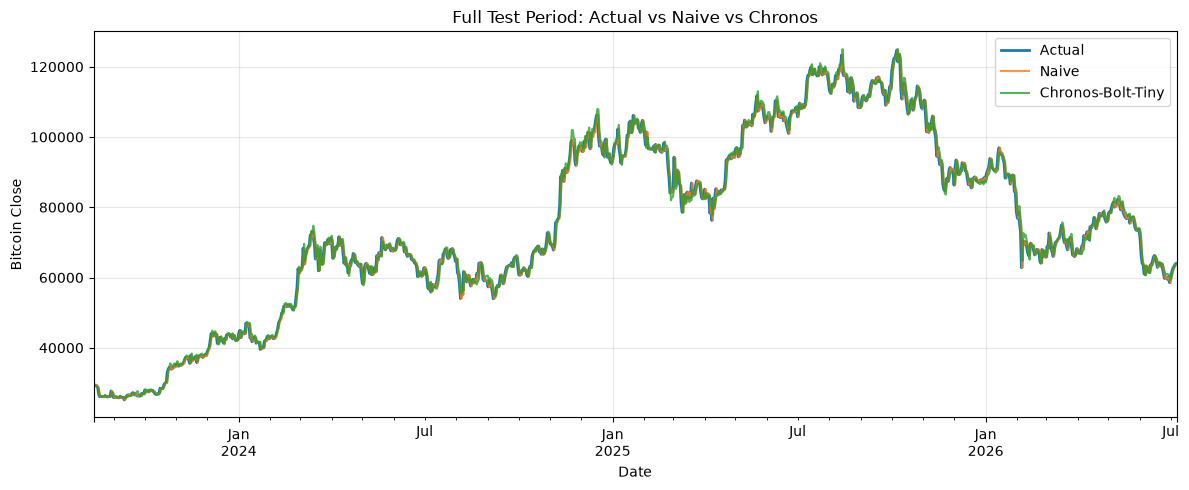

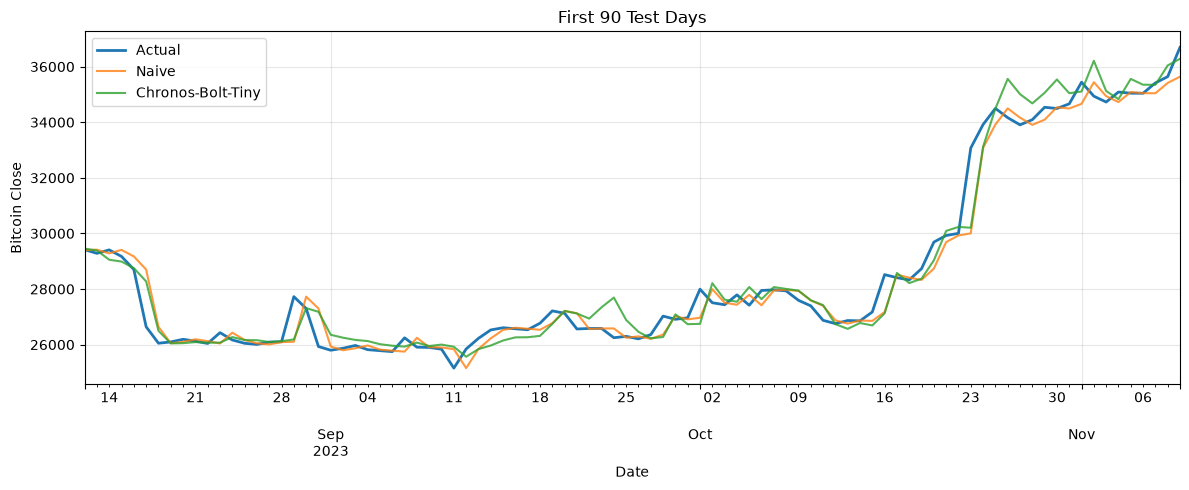

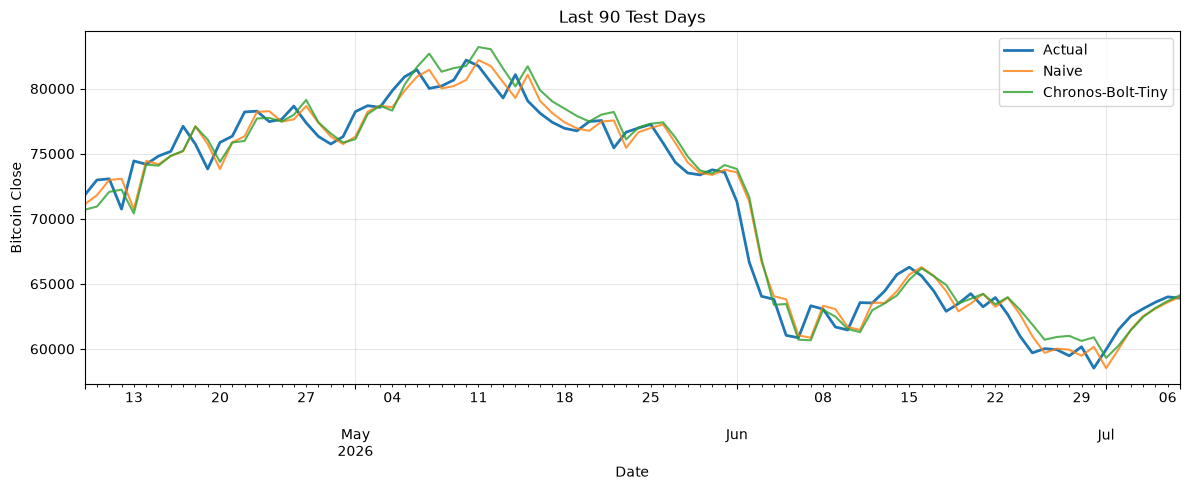

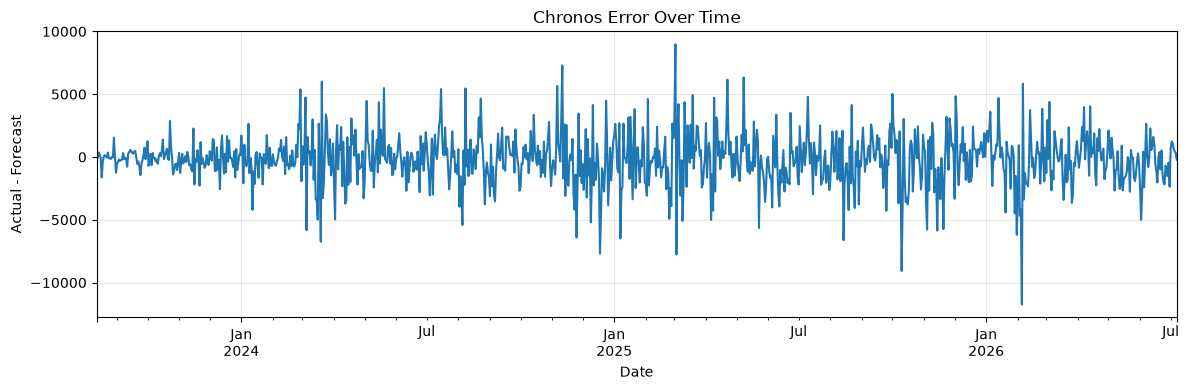

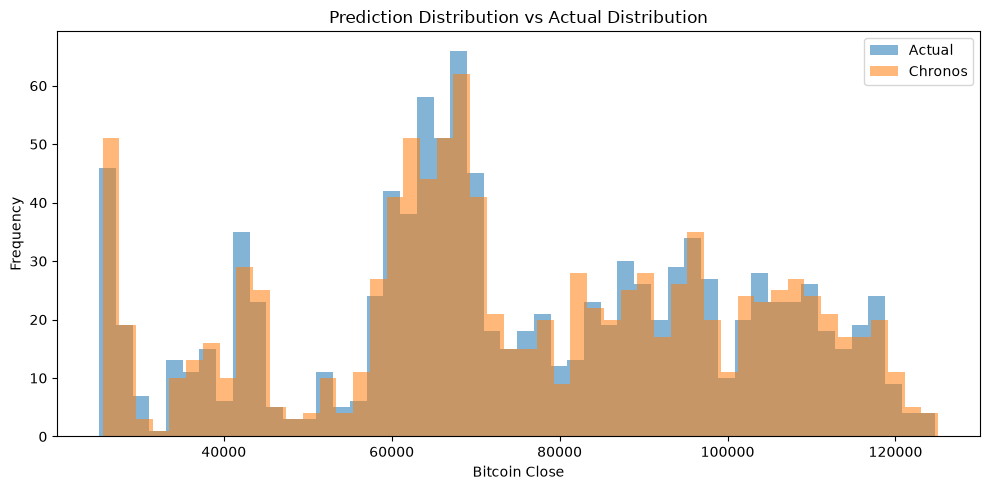

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
y_test.plot(ax=ax, label="Actual", linewidth=2)
naive_forecast.plot(ax=ax, label="Naive", alpha=0.8)
chronos_forecast.plot(ax=ax, label="Chronos-Bolt-Tiny", alpha=0.8)
ax.set_title("Full Test Period: Actual vs Naive vs Chronos")
ax.set_xlabel("Date")
ax.set_ylabel("Bitcoin Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
y_test.head(90).plot(ax=ax, label="Actual", linewidth=2)
naive_forecast.head(90).plot(ax=ax, label="Naive", alpha=0.8)
chronos_forecast.head(90).plot(ax=ax, label="Chronos-Bolt-Tiny", alpha=0.8)
ax.set_title("First 90 Test Days")
ax.set_xlabel("Date")
ax.set_ylabel("Bitcoin Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
y_test.tail(90).plot(ax=ax, label="Actual", linewidth=2)
naive_forecast.tail(90).plot(ax=ax, label="Naive", alpha=0.8)
chronos_forecast.tail(90).plot(ax=ax, label="Chronos-Bolt-Tiny", alpha=0.8)
ax.set_title("Last 90 Test Days")
ax.set_xlabel("Date")
ax.set_ylabel("Bitcoin Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
chronos_error.plot(ax=ax)
ax.set_title("Chronos Error Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Actual - Forecast")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
y_test.plot(kind="hist", bins=50, alpha=0.55, ax=ax, label="Actual")
chronos_forecast.plot(kind="hist", bins=50, alpha=0.55, ax=ax, label="Chronos")
ax.set_title("Prediction Distribution vs Actual Distribution")
ax.set_xlabel("Bitcoin Close")
ax.legend()
plt.tight_layout()
plt.show()


In [16]:
def metrics_for_subset(name, mask):
    actual_subset = y_test.loc[mask]
    forecast_subset = chronos_forecast.loc[mask]
    return {
        "Regime": name,
        "Rows": len(actual_subset),
        "MAE": mae(actual_subset, forecast_subset),
        "RMSE": rmse(actual_subset, forecast_subset),
        "MAPE": mape(actual_subset, forecast_subset),
        "sMAPE": smape(actual_subset, forecast_subset),
    }


returns = target.pct_change().reindex(test.index)
rolling_volatility = returns.rolling(window=30, min_periods=10).std()
low_vol_threshold = rolling_volatility.quantile(0.25)
high_vol_threshold = rolling_volatility.quantile(0.75)
movement_threshold = returns.abs().quantile(0.75)

regime_table = pd.DataFrame(
    [
        metrics_for_subset("Low volatility", rolling_volatility <= low_vol_threshold),
        metrics_for_subset("High volatility", rolling_volatility >= high_vol_threshold),
        metrics_for_subset("Major upward movement", returns >= movement_threshold),
        metrics_for_subset("Major downward movement", returns <= -movement_threshold),
    ]
).set_index("Regime")
regime_table


,Rows,MAE,RMSE,MAPE,sMAPE
Regime,,,,,
Low volatility,263,1248.161988,1706.361802,1.457608,1.451969
High volatility,263,1871.323135,2539.070134,2.671100,2.659517
Major upward movement,141,2741.499929,3136.445465,3.795811,3.888166
Major downward movement,125,3334.871796,3755.413182,4.630048,4.502508


In [17]:
segment_labels = pd.qcut(np.arange(len(test)), q=3, labels=["Earlier test period", "Middle test period", "Later test period"])
segment_table = pd.DataFrame(
    [
        {
            "Segment": segment,
            "Rows": int((segment_labels == segment).sum()),
            "Start Date": y_test.index[segment_labels == segment].min(),
            "End Date": y_test.index[segment_labels == segment].max(),
            "MAE": mae(y_test.loc[segment_labels == segment], chronos_forecast.loc[segment_labels == segment]),
            "RMSE": rmse(y_test.loc[segment_labels == segment], chronos_forecast.loc[segment_labels == segment]),
            "MAPE": mape(y_test.loc[segment_labels == segment], chronos_forecast.loc[segment_labels == segment]),
            "sMAPE": smape(y_test.loc[segment_labels == segment], chronos_forecast.loc[segment_labels == segment]),
        }
        for segment in segment_labels.categories
    ]
).set_index("Segment")
segment_table


,Rows,Start Date,End Date,MAE,RMSE,MAPE,sMAPE
Segment,,,,,,,
Earlier test period,354,2023-08-12 00:00:00+00:00,2024-07-30 00:00:00+00:00,1033.215942,1531.946847,2.008502,2.005858
Middle test period,353,2024-07-31 00:00:00+00:00,2025-07-18 00:00:00+00:00,1674.153152,2250.580111,1.974458,1.971721
Later test period,354,2025-07-19 00:00:00+00:00,2026-07-07 00:00:00+00:00,1565.414964,2125.866235,1.820680,1.808889


In [18]:
def interval_coverage(lower_level, upper_level, label):
    lower = chronos_quantiles[lower_level]
    upper = chronos_quantiles[upper_level]
    covered = ((y_test >= lower) & (y_test <= upper)).mean()
    width = (upper - lower).mean()
    return {
        "Interval": label,
        "Lower Quantile": lower_level,
        "Upper Quantile": upper_level,
        "Coverage": covered,
        "Average Width": width,
        "Quantiles Verified From API Request": (lower_level in CHRONOS_QUANTILE_LEVELS) and (upper_level in CHRONOS_QUANTILE_LEVELS),
    }


uncertainty_rows = [interval_coverage(0.1, 0.9, "80%")]
if 0.025 in CHRONOS_QUANTILE_LEVELS and 0.975 in CHRONOS_QUANTILE_LEVELS:
    uncertainty_rows.append(interval_coverage(0.025, 0.975, "95%"))
else:
    uncertainty_rows.append(
        {
            "Interval": "95%",
            "Lower Quantile": np.nan,
            "Upper Quantile": np.nan,
            "Coverage": np.nan,
            "Average Width": np.nan,
            "Quantiles Verified From API Request": False,
            "Note": "Not available: Chronos-Bolt exposes trained quantiles from 0.1 to 0.9 in this API.",
        }
    )
uncertainty_table = pd.DataFrame(uncertainty_rows).set_index("Interval")
uncertainty_table


,Lower Quantile,Upper Quantile,Coverage,Average Width,Quantiles Verified From API Request,Note
Interval,,,,,,
80%,0.100000,0.900000,0.845429,5151.959961,True,NaN
95%,NaN,NaN,NaN,NaN,False,Not available: Chronos-Bolt exposes trained qu...


In [19]:
forecast_to_actual_std_ratio = chronos_forecast.std() / y_test.std()
daily_change_std_ratio = chronos_forecast.diff().std() / y_test.diff().std()
range_compression_ratio = (chronos_forecast.max() - chronos_forecast.min()) / (y_test.max() - y_test.min())

chronos_diagnostics_table = pd.DataFrame(
    [
        {"Check": "Constant prediction", "Value": bool(chronos_forecast.nunique(dropna=True) <= 1)},
        {"Check": "Range compression ratio", "Value": range_compression_ratio},
        {"Check": "Forecast-to-actual std ratio", "Value": forecast_to_actual_std_ratio},
        {"Check": "Daily-change std ratio", "Value": daily_change_std_ratio},
        {"Check": "Exact index alignment", "Value": chronos_forecast.index.equals(y_test.index)},
        {"Check": "Forecast length", "Value": len(chronos_forecast)},
        {"Check": "Test length", "Value": len(y_test)},
        {"Check": "Missing predictions", "Value": int(chronos_forecast.isna().sum())},
        {"Check": "Finite predictions", "Value": bool(np.isfinite(chronos_forecast.to_numpy()).all())},
        {"Check": "Raw quantile output shape", "Value": chronos_quantile_array.shape},
        {"Check": "Mean output shape", "Value": chronos_mean_array.shape},
        {"Check": "Quantile levels requested", "Value": CHRONOS_QUANTILE_LEVELS},
        {"Check": "Inference time seconds", "Value": chronos_inference_time_seconds},
        {"Check": "Average inference seconds per forecast", "Value": chronos_inference_time_seconds / len(test)},
    ]
).set_index("Check")

display(chronos_first_10)
chronos_diagnostics_table


,context_start_date,context_end_date,last_context_value,actual_value,naive_forecast,chronos_forecast
forecast_date,,,,,,
2023-08-12 00:00:00+00:00,2023-04-06 00:00:00+00:00,2023-08-11 00:00:00+00:00,29398.000000,29415.000000,29398.000000,29454.222656
2023-08-13 00:00:00+00:00,2023-04-07 00:00:00+00:00,2023-08-12 00:00:00+00:00,29415.000000,29284.000000,29415.000000,29386.662109
2023-08-14 00:00:00+00:00,2023-04-08 00:00:00+00:00,2023-08-13 00:00:00+00:00,29284.000000,29408.000000,29284.000000,29053.404297
2023-08-15 00:00:00+00:00,2023-04-09 00:00:00+00:00,2023-08-14 00:00:00+00:00,29408.000000,29172.000000,29408.000000,28988.236328
2023-08-16 00:00:00+00:00,2023-04-10 00:00:00+00:00,2023-08-15 00:00:00+00:00,29172.000000,28701.000000,29172.000000,28751.792969
2023-08-17 00:00:00+00:00,2023-04-11 00:00:00+00:00,2023-08-16 00:00:00+00:00,28701.000000,26642.000000,28701.000000,28273.064453
2023-08-18 00:00:00+00:00,2023-04-12 00:00:00+00:00,2023-08-17 00:00:00+00:00,26642.000000,26051.000000,26642.000000,26497.435547
2023-08-19 00:00:00+00:00,2023-04-13 00:00:00+00:00,2023-08-18 00:00:00+00:00,26051.000000,26097.000000,26051.000000,26045.431641
2023-08-20 00:00:00+00:00,2023-04-14 00:00:00+00:00,2023-08-19 00:00:00+00:00,26097.000000,26192.000000,26097.000000,26052.617188


,Value
Check,
Constant prediction,False
Range compression ratio,0.999340
Forecast-to-actual std ratio,1.004041
Daily-change std ratio,0.986677
Exact index alignment,True
Forecast length,1061
Test length,1061
Missing predictions,0
Finite predictions,True


## 7. TimesFM

TimesFM is tested here with a smoke test only. The package has been installed in the current Python 3.13 project environment and the import check passed.

The smallest available model exposed by the installed `timesfm==2.0.2` package is `google/timesfm-2.5-200m-pytorch`. This section loads that model on CPU, compiles it for a 128-day context and 7-day horizon, and forecasts only the next seven days after the training period.

This is **not** a full rolling evaluation. If the smoke test succeeds, the notebook records TimesFM as locally runnable, but `timesfm_forecast` remains `None` so it is not included in the full benchmark tables yet.


In [20]:
timesfm_status = {
    "Model": "TimesFM",
    "Zero-shot or Fine-tuned": "Zero-shot",
    "Package Available": package_available("timesfm"),
    "Installed Version": "2.0.2" if package_available("timesfm") else None,
    "Selected Model": "google/timesfm-2.5-200m-pytorch",
    "Protocol Attempted": "Rolling one-step",
    "Runnable Now": package_available("timesfm") and torch is not None,
    "Blocker": None,
}

if not package_available("timesfm"):
    timesfm_status["Blocker"] = "timesfm is not installed in the current environment."
elif torch is None:
    timesfm_status["Blocker"] = "PyTorch is not importable."
else:
    timesfm_status["Blocker"] = "Runnable guard passed; full rolling one-step evaluation completed below."

pd.DataFrame([timesfm_status])


,Model,Zero-shot or Fine-tuned,Package Available,Installed Version,Selected Model,Protocol Attempted,Runnable Now,Blocker
0,TimesFM,Zero-shot,True,2.0.2,google/timesfm-2.5-200m-pytorch,Rolling one-step,True,Runnable guard passed; full rolling one-step e...


Python version: 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]
Interpreter: E:\Re_Sc_AM\TimeSeriesFoundationModels\.venv\Scripts\python.exe
PyTorch version: 2.12.1+cpu
CUDA available: False
Total RAM GB: 15.34
Available RAM GB before loading: 4.25
TimesFM import passed
TimesFM version: unknown


pip check output:
No broken requirements found.


Selected model: google/timesfm-2.5-200m-pytorch
Model loading time seconds: 3.336
Inference time seconds: 0.309
RAM before loading GB: 4.26
RAM after loading GB: 3.41
Output shape: (7,)
Quantile output shape: (1, 7, 10)
Forecast values: [29464.43359375, 29485.19140625, 29435.271484375, 29447.951171875, 29336.814453125, 29355.107421875, 29411.11328125]
Min: 29336.814453125
Max: 29485.19140625
Mean: 29419.412109375
Std: 51.333900451660156
Finite prediction check: True
Constant prediction check: False


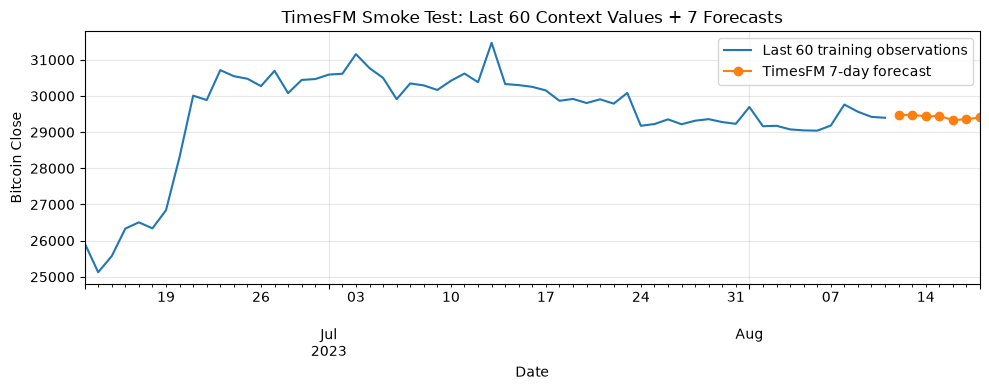

In [21]:
import subprocess

RUN_TIMESFM_SMOKE_TEST = True
timesfm_forecast = None
timesfm_inference_time_seconds = np.nan
timesfm_smoke_forecast = None
timesfm_smoke_quantiles = None

if RUN_TIMESFM_SMOKE_TEST:
    import timesfm

    print("Python version:", sys.version)
    print("Interpreter:", sys.executable)
    print("PyTorch version:", torch.__version__ if torch else "Not installed")
    print("CUDA available:", torch.cuda.is_available() if torch else False)
    print(f"Total RAM GB: {total_ram_gb:.2f}")
    print(f"Available RAM GB before loading: {psutil.virtual_memory().available / 1024**3:.2f}")
    print("TimesFM import passed")
    print("TimesFM version:", getattr(timesfm, "__version__", "unknown"))

    pip_check = subprocess.run(
        [sys.executable, "-m", "pip", "check"],
        capture_output=True,
        text=True,
        check=False,
    )
    print("pip check output:")
    print(pip_check.stdout.strip() or pip_check.stderr.strip())

    TIMESFM_MODEL_ID = timesfm.TimesFM_2p5_200M_torch.DEFAULT_REPO_ID
    TIMESFM_CONTEXT_LENGTH = 128
    TIMESFM_HORIZON = 7
    timesfm_context = train.tail(TIMESFM_CONTEXT_LENGTH).to_numpy(dtype=np.float32)

    ram_before_timesfm_load_gb = psutil.virtual_memory().available / 1024**3
    timesfm_load_start = time.perf_counter()
    timesfm_model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
        TIMESFM_MODEL_ID,
        torch_compile=False,
    )
    timesfm_model.compile(
        timesfm.ForecastConfig(
            max_context=TIMESFM_CONTEXT_LENGTH,
            max_horizon=TIMESFM_HORIZON,
            normalize_inputs=True,
            per_core_batch_size=1,
        )
    )
    timesfm_model_load_seconds = time.perf_counter() - timesfm_load_start
    ram_after_timesfm_load_gb = psutil.virtual_memory().available / 1024**3

    timesfm_inference_start = time.perf_counter()
    timesfm_point_forecast, timesfm_quantile_forecast = timesfm_model.forecast(
        horizon=TIMESFM_HORIZON,
        inputs=[timesfm_context],
    )
    timesfm_inference_time_seconds = time.perf_counter() - timesfm_inference_start

    timesfm_smoke_forecast = np.asarray(timesfm_point_forecast)[0]
    timesfm_smoke_quantiles = np.asarray(timesfm_quantile_forecast)

    print("Selected model:", TIMESFM_MODEL_ID)
    print("Model loading time seconds:", round(timesfm_model_load_seconds, 3))
    print("Inference time seconds:", round(timesfm_inference_time_seconds, 3))
    print("RAM before loading GB:", round(ram_before_timesfm_load_gb, 2))
    print("RAM after loading GB:", round(ram_after_timesfm_load_gb, 2))
    print("Output shape:", timesfm_smoke_forecast.shape)
    print("Quantile output shape:", timesfm_smoke_quantiles.shape)
    print("Forecast values:", timesfm_smoke_forecast.tolist())
    print("Min:", float(np.min(timesfm_smoke_forecast)))
    print("Max:", float(np.max(timesfm_smoke_forecast)))
    print("Mean:", float(np.mean(timesfm_smoke_forecast)))
    print("Std:", float(np.std(timesfm_smoke_forecast)))
    print("Finite prediction check:", bool(np.isfinite(timesfm_smoke_forecast).all()))
    print("Constant prediction check:", bool(np.unique(np.round(timesfm_smoke_forecast, 8)).size <= 1))

    timesfm_smoke_index = pd.date_range(
        train.index[-1] + pd.Timedelta(days=1),
        periods=TIMESFM_HORIZON,
        freq="D",
        tz=train.index.tz,
    )
    timesfm_smoke_series = pd.Series(timesfm_smoke_forecast, index=timesfm_smoke_index, name="TimesFM Smoke Forecast")

    fig, ax = plt.subplots(figsize=(10, 4))
    train.tail(60).plot(ax=ax, label="Last 60 training observations")
    timesfm_smoke_series.plot(ax=ax, label="TimesFM 7-day forecast", marker="o")
    ax.set_title("TimesFM Smoke Test: Last 60 Context Values + 7 Forecasts")
    ax.set_xlabel("Date")
    ax.set_ylabel("Bitcoin Close")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Full TimesFM Rolling One-Step Evaluation

This section evaluates `google/timesfm-2.5-200m-pytorch` using the same Bitcoin daily test period and the same fair rolling one-step protocol used for Chronos. Each forecast for date `t` uses a fixed 128-day context ending strictly before `t`. Context windows are built first, then passed to the TimesFM API as a batch-capable input list.

Protocol labels:
- Model type: zero-shot time-series foundation model.
- Evaluation: rolling one-step.
- Device: CPU.
- Context length: 128 days.
- Horizon: 1 day.


In [22]:
import timesfm

TIMESFM_MODEL_ID = "google/timesfm-2.5-200m-pytorch"
TIMESFM_CONTEXT_LENGTH = 128
TIMESFM_HORIZON = 1
TIMESFM_PER_CORE_BATCH_SIZE = 32
TIMESFM_QUANTILE_LEVELS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

assert train.index.max() == pd.Timestamp("2023-08-11", tz="UTC")
assert test.index.min() == pd.Timestamp("2023-08-12", tz="UTC")
assert len(test) == 1061

timesfm_contexts = []
timesfm_context_start_dates = []
timesfm_context_end_dates = []
timesfm_last_context_values = []

for forecast_date in test.index:
    history_before_forecast = target[target.index < forecast_date]
    context_window = history_before_forecast.tail(TIMESFM_CONTEXT_LENGTH)
    assert len(context_window) == TIMESFM_CONTEXT_LENGTH
    assert context_window.index.max() < forecast_date

    timesfm_contexts.append(context_window.to_numpy(dtype=np.float32))
    timesfm_context_start_dates.append(context_window.index.min())
    timesfm_context_end_dates.append(context_window.index.max())
    timesfm_last_context_values.append(float(context_window.iloc[-1]))

timesfm_audit_preview = pd.DataFrame(
    {
        "forecast_date": test.index[:10],
        "context_start_date": timesfm_context_start_dates[:10],
        "context_end_date": timesfm_context_end_dates[:10],
        "last_context_value": timesfm_last_context_values[:10],
        "actual_value": y_test.iloc[:10].to_numpy(dtype=float),
        "naive_forecast": naive_forecast.iloc[:10].to_numpy(dtype=float),
    }
)
timesfm_audit_preview


,forecast_date,context_start_date,context_end_date,last_context_value,actual_value,naive_forecast
0,2023-08-12 00:00:00+00:00,2023-04-06 00:00:00+00:00,2023-08-11 00:00:00+00:00,29398.000000,29415.000000,29398.000000
1,2023-08-13 00:00:00+00:00,2023-04-07 00:00:00+00:00,2023-08-12 00:00:00+00:00,29415.000000,29284.000000,29415.000000
2,2023-08-14 00:00:00+00:00,2023-04-08 00:00:00+00:00,2023-08-13 00:00:00+00:00,29284.000000,29408.000000,29284.000000
3,2023-08-15 00:00:00+00:00,2023-04-09 00:00:00+00:00,2023-08-14 00:00:00+00:00,29408.000000,29172.000000,29408.000000
4,2023-08-16 00:00:00+00:00,2023-04-10 00:00:00+00:00,2023-08-15 00:00:00+00:00,29172.000000,28701.000000,29172.000000
5,2023-08-17 00:00:00+00:00,2023-04-11 00:00:00+00:00,2023-08-16 00:00:00+00:00,28701.000000,26642.000000,28701.000000
6,2023-08-18 00:00:00+00:00,2023-04-12 00:00:00+00:00,2023-08-17 00:00:00+00:00,26642.000000,26051.000000,26642.000000
7,2023-08-19 00:00:00+00:00,2023-04-13 00:00:00+00:00,2023-08-18 00:00:00+00:00,26051.000000,26097.000000,26051.000000
8,2023-08-20 00:00:00+00:00,2023-04-14 00:00:00+00:00,2023-08-19 00:00:00+00:00,26097.000000,26192.000000,26097.000000
9,2023-08-21 00:00:00+00:00,2023-04-15 00:00:00+00:00,2023-08-20 00:00:00+00:00,26192.000000,26125.000000,26192.000000


In [23]:
timesfm_ram_before_load_gb = psutil.virtual_memory().available / 1024**3 if psutil else np.nan
timesfm_load_start = time.perf_counter()
timesfm_model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    TIMESFM_MODEL_ID,
    torch_compile=False,
)
timesfm_model.compile(
    timesfm.ForecastConfig(
        max_context=TIMESFM_CONTEXT_LENGTH,
        max_horizon=TIMESFM_HORIZON,
        normalize_inputs=True,
        per_core_batch_size=TIMESFM_PER_CORE_BATCH_SIZE,
    )
)
timesfm_model_load_seconds = time.perf_counter() - timesfm_load_start
timesfm_ram_after_load_gb = psutil.virtual_memory().available / 1024**3 if psutil else np.nan

timesfm_inference_start = time.perf_counter()
timesfm_point_array, timesfm_quantile_array = timesfm_model.forecast(
    horizon=TIMESFM_HORIZON,
    inputs=timesfm_contexts,
)
timesfm_inference_time_seconds = time.perf_counter() - timesfm_inference_start

timesfm_point_array = np.asarray(timesfm_point_array, dtype=float)
timesfm_quantile_array = np.asarray(timesfm_quantile_array, dtype=float)
timesfm_point_values = timesfm_point_array[:, 0] if timesfm_point_array.ndim == 2 else timesfm_point_array.reshape(len(test), -1)[:, 0]
timesfm_forecast = pd.Series(timesfm_point_values, index=test.index, name="TimesFM")

assert len(timesfm_forecast) == 1061
assert timesfm_forecast.index.equals(y_test.index)
assert timesfm_forecast.index.is_unique
assert timesfm_forecast.isna().sum() == 0
assert np.isfinite(timesfm_forecast.to_numpy(dtype=float)).all()

timesfm_audit_preview["timesfm_forecast"] = timesfm_forecast.iloc[:10].to_numpy(dtype=float)
assert (pd.to_datetime(timesfm_audit_preview["context_end_date"]) < pd.to_datetime(timesfm_audit_preview["forecast_date"])).all()
timesfm_audit_preview


,forecast_date,context_start_date,context_end_date,last_context_value,actual_value,naive_forecast,timesfm_forecast
0,2023-08-12 00:00:00+00:00,2023-04-06 00:00:00+00:00,2023-08-11 00:00:00+00:00,29398.000000,29415.000000,29398.000000,29464.433594
1,2023-08-13 00:00:00+00:00,2023-04-07 00:00:00+00:00,2023-08-12 00:00:00+00:00,29415.000000,29284.000000,29415.000000,29481.603516
2,2023-08-14 00:00:00+00:00,2023-04-08 00:00:00+00:00,2023-08-13 00:00:00+00:00,29284.000000,29408.000000,29284.000000,29383.083984
3,2023-08-15 00:00:00+00:00,2023-04-09 00:00:00+00:00,2023-08-14 00:00:00+00:00,29408.000000,29172.000000,29408.000000,29387.412109
4,2023-08-16 00:00:00+00:00,2023-04-10 00:00:00+00:00,2023-08-15 00:00:00+00:00,29172.000000,28701.000000,29172.000000,29283.365234
5,2023-08-17 00:00:00+00:00,2023-04-11 00:00:00+00:00,2023-08-16 00:00:00+00:00,28701.000000,26642.000000,28701.000000,28895.416016
6,2023-08-18 00:00:00+00:00,2023-04-12 00:00:00+00:00,2023-08-17 00:00:00+00:00,26642.000000,26051.000000,26642.000000,27035.302734
7,2023-08-19 00:00:00+00:00,2023-04-13 00:00:00+00:00,2023-08-18 00:00:00+00:00,26051.000000,26097.000000,26051.000000,26035.308594
8,2023-08-20 00:00:00+00:00,2023-04-14 00:00:00+00:00,2023-08-19 00:00:00+00:00,26097.000000,26192.000000,26097.000000,26053.943359
9,2023-08-21 00:00:00+00:00,2023-04-15 00:00:00+00:00,2023-08-20 00:00:00+00:00,26192.000000,26125.000000,26192.000000,26101.970703


In [24]:
timesfm_error = y_test - timesfm_forecast
timesfm_metrics = pd.DataFrame(
    [
        {
            "Model": "TimesFM",
            "Protocol": "Rolling one-step",
            "MAE": mae(y_test, timesfm_forecast),
            "RMSE": rmse(y_test, timesfm_forecast),
            "MAPE": mape(y_test, timesfm_forecast),
            "sMAPE": smape(y_test, timesfm_forecast),
            "Relative MAE vs Naive": mae(y_test, timesfm_forecast) / mae(y_test, naive_forecast),
            "Prediction Min": timesfm_forecast.min(),
            "Prediction Max": timesfm_forecast.max(),
            "Prediction Mean": timesfm_forecast.mean(),
            "Prediction Std": timesfm_forecast.std(),
            "Actual Std": y_test.std(),
            "Prediction Daily-Change Std": timesfm_forecast.diff().std(),
            "Actual Daily-Change Std": y_test.diff().std(),
            "Daily-Change Std Ratio": timesfm_forecast.diff().std() / y_test.diff().std(),
            "Correlation With Actual": y_test.corr(timesfm_forecast),
            "Model Load Seconds": timesfm_model_load_seconds,
            "Total Inference Seconds": timesfm_inference_time_seconds,
            "Average Inference Seconds Per Forecast": timesfm_inference_time_seconds / len(test),
        }
    ]
).set_index("Model")
timesfm_metrics


,Protocol,MAE,RMSE,MAPE,sMAPE,Relative MAE vs Naive,Prediction Min,Prediction Max,Prediction Mean,Prediction Std,Actual Std,Prediction Daily-Change Std,Actual Daily-Change Std,Daily-Change Std Ratio,Correlation With Actual,Model Load Seconds,Total Inference Seconds,Average Inference Seconds Per Forecast
Model,,,,,,,,,,,,,,,,,,
TimesFM,Rolling one-step,1349.946786,1924.199337,1.823179,1.823895,1.046184,25473.763672,124593.343750,75127.860977,25571.139843,25564.279690,1744.346287,1855.088666,0.940303,0.997167,3.238607,35.396255,0.033361


In [25]:
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)

timesfm_artifact = pd.DataFrame(
    {
        "Timestamp": timesfm_forecast.index,
        "TimesFM": timesfm_forecast.to_numpy(dtype=float),
    }
)

assert timesfm_artifact.shape == (1061, 2)
assert timesfm_artifact["Timestamp"].is_unique
assert timesfm_artifact["Timestamp"].is_monotonic_increasing
assert not timesfm_artifact.isna().any().any()
assert np.isfinite(timesfm_artifact["TimesFM"].to_numpy(dtype=float)).all()

timesfm_artifact_path = results_dir / "timesfm_forecast.csv"
timesfm_artifact.to_csv(timesfm_artifact_path, index=False)

persistence_artifact_path = results_dir / "persistence_enhanced_lstm_forecast.csv"
persistence_artifact = pd.read_csv(persistence_artifact_path, parse_dates=["Timestamp"])
assert persistence_artifact.shape == (1061, 2)
assert persistence_artifact.columns.tolist() == ["Timestamp", "Persistence_Enhanced_LSTM"]

validated_forecast_path = results_dir / "validated_forecasts.csv"
validated_forecasts = pd.read_csv(validated_forecast_path, parse_dates=["Timestamp"])
validated_forecasts = validated_forecasts.drop(columns=["Persistence_Enhanced_LSTM", "TimesFM"], errors="ignore")
validated_forecasts = validated_forecasts.merge(
    persistence_artifact,
    on="Timestamp",
    how="inner",
    validate="one_to_one",
)
validated_forecasts = validated_forecasts.merge(
    timesfm_artifact,
    on="Timestamp",
    how="inner",
    validate="one_to_one",
)
validated_forecasts = validated_forecasts[
    ["Timestamp", "Actual", "Naive", "Persistence_Enhanced_LSTM", "Chronos_Bolt_Tiny", "TimesFM"]
]

assert validated_forecasts.shape == (1061, 6)
assert validated_forecasts["Timestamp"].is_unique
assert validated_forecasts["Timestamp"].is_monotonic_increasing
assert not validated_forecasts.isna().any().any()
assert np.isfinite(
    validated_forecasts[["Actual", "Naive", "Persistence_Enhanced_LSTM", "Chronos_Bolt_Tiny", "TimesFM"]].to_numpy(dtype=float)
).all()

validated_forecasts.to_csv(validated_forecast_path, index=False)

artifact_validation = pd.DataFrame(
    [
        {"Artifact": "timesfm_forecast.csv", "Shape": timesfm_artifact.shape, "Valid": True},
        {"Artifact": "validated_forecasts.csv", "Shape": validated_forecasts.shape, "Valid": True},
    ]
)
artifact_validation


,Artifact,Shape,Valid
0,timesfm_forecast.csv,"(1061, 2)",True
1,validated_forecasts.csv,"(1061, 6)",True


In [26]:
authoritative_comparison = pd.DataFrame(
    [
        {
            "Model": "Naive",
            "MAE": mae(validated_forecasts["Actual"], validated_forecasts["Naive"]),
            "RMSE": rmse(validated_forecasts["Actual"], validated_forecasts["Naive"]),
            "MAPE": mape(validated_forecasts["Actual"], validated_forecasts["Naive"]),
            "sMAPE": smape(validated_forecasts["Actual"], validated_forecasts["Naive"]),
        },
        {
            "Model": "Persistence-Enhanced LSTM",
            "MAE": mae(validated_forecasts["Actual"], validated_forecasts["Persistence_Enhanced_LSTM"]),
            "RMSE": rmse(validated_forecasts["Actual"], validated_forecasts["Persistence_Enhanced_LSTM"]),
            "MAPE": mape(validated_forecasts["Actual"], validated_forecasts["Persistence_Enhanced_LSTM"]),
            "sMAPE": smape(validated_forecasts["Actual"], validated_forecasts["Persistence_Enhanced_LSTM"]),
        },
        {
            "Model": "Chronos-Bolt-Tiny",
            "MAE": mae(validated_forecasts["Actual"], validated_forecasts["Chronos_Bolt_Tiny"]),
            "RMSE": rmse(validated_forecasts["Actual"], validated_forecasts["Chronos_Bolt_Tiny"]),
            "MAPE": mape(validated_forecasts["Actual"], validated_forecasts["Chronos_Bolt_Tiny"]),
            "sMAPE": smape(validated_forecasts["Actual"], validated_forecasts["Chronos_Bolt_Tiny"]),
        },
        {
            "Model": "TimesFM",
            "MAE": mae(validated_forecasts["Actual"], validated_forecasts["TimesFM"]),
            "RMSE": rmse(validated_forecasts["Actual"], validated_forecasts["TimesFM"]),
            "MAPE": mape(validated_forecasts["Actual"], validated_forecasts["TimesFM"]),
            "sMAPE": smape(validated_forecasts["Actual"], validated_forecasts["TimesFM"]),
        },
        {
            "Model": "7-Day Moving Average",
            "MAE": mae(y_test, moving_average_7),
            "RMSE": rmse(y_test, moving_average_7),
            "MAPE": mape(y_test, moving_average_7),
            "sMAPE": smape(y_test, moving_average_7),
        },
    ]
).set_index("Model")

authoritative_comparison["Relative MAE vs Naive"] = authoritative_comparison["MAE"] / authoritative_comparison.loc["Naive", "MAE"]
authoritative_comparison.sort_values("RMSE")


,MAE,RMSE,MAPE,sMAPE,Relative MAE vs Naive
Model,,,,,
Naive,1290.353242,1853.624774,1.742747,1.744142,1.000000
Persistence-Enhanced LSTM,1321.365311,1881.091190,1.783956,1.791645,1.024034
TimesFM,1349.946786,1924.199337,1.823179,1.823895,1.046184
Chronos-Bolt-Tiny,1424.025828,1994.007926,1.934509,1.928782,1.103594
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208,1.712536


In [27]:
timesfm_returns = y_test.pct_change()
timesfm_rolling_volatility = timesfm_returns.rolling(window=14, min_periods=7).std()
timesfm_low_threshold = timesfm_rolling_volatility.quantile(0.33)
timesfm_high_threshold = timesfm_rolling_volatility.quantile(0.67)
timesfm_up_threshold = timesfm_returns.quantile(0.80)
timesfm_down_threshold = timesfm_returns.quantile(0.20)

timesfm_regime_masks = {
    "Low Volatility": timesfm_rolling_volatility <= timesfm_low_threshold,
    "High Volatility": timesfm_rolling_volatility >= timesfm_high_threshold,
    "Major Upward Movement": timesfm_returns >= timesfm_up_threshold,
    "Major Downward Movement": timesfm_returns <= timesfm_down_threshold,
}

timesfm_regime_rows = []
for regime_name, mask in timesfm_regime_masks.items():
    regime_index = mask[mask].index
    scores = {
        "MAE": mae(y_test.reindex(regime_index), timesfm_forecast.reindex(regime_index)),
        "RMSE": rmse(y_test.reindex(regime_index), timesfm_forecast.reindex(regime_index)),
        "MAPE": mape(y_test.reindex(regime_index), timesfm_forecast.reindex(regime_index)),
        "sMAPE": smape(y_test.reindex(regime_index), timesfm_forecast.reindex(regime_index)),
        "N": len(regime_index),
    }
    scores.update({"Regime": regime_name})
    timesfm_regime_rows.append(scores)

timesfm_regime_table = pd.DataFrame(timesfm_regime_rows).set_index("Regime")
timesfm_regime_table


,MAE,RMSE,MAPE,sMAPE,N
Regime,,,,,
Low Volatility,1004.046175,1395.964951,1.262562,1.264101,348
High Volatility,1725.906316,2431.334540,2.463589,2.468897,348
Major Upward Movement,2467.687670,2877.414558,3.379197,3.454914,212
Major Downward Movement,2454.908958,2875.542493,3.353373,3.279358,212


In [28]:
timesfm_segment_rows = []
for segment_name, segment_index in zip(
    ["Earlier Test Period", "Middle Test Period", "Later Test Period"],
    np.array_split(y_test.index, 3),
):
    timesfm_segment_rows.append(
        {
            "Segment": segment_name,
            "MAE": mae(y_test.reindex(segment_index), timesfm_forecast.reindex(segment_index)),
            "RMSE": rmse(y_test.reindex(segment_index), timesfm_forecast.reindex(segment_index)),
            "MAPE": mape(y_test.reindex(segment_index), timesfm_forecast.reindex(segment_index)),
            "sMAPE": smape(y_test.reindex(segment_index), timesfm_forecast.reindex(segment_index)),
            "N": len(segment_index),
        }
    )

timesfm_segment_table = pd.DataFrame(timesfm_segment_rows).set_index("Segment")
timesfm_segment_table


,MAE,RMSE,MAPE,sMAPE,N
Segment,,,,,
Earlier Test Period,959.797107,1447.154027,1.856881,1.863368,354
Middle Test Period,1623.767368,2221.895875,1.901097,1.906334,354
Later Test Period,1466.605426,2019.309963,1.711244,1.701637,353


In [29]:
timesfm_available_quantiles = TIMESFM_QUANTILE_LEVELS
timesfm_uncertainty_rows = []

if timesfm_quantile_array.ndim == 3 and 0.1 in timesfm_available_quantiles and 0.9 in timesfm_available_quantiles:
    timesfm_lower_80 = pd.Series(
        timesfm_quantile_array[:, 0, timesfm_available_quantiles.index(0.1)],
        index=y_test.index,
        name="TimesFM q0.1",
    )
    timesfm_upper_80 = pd.Series(
        timesfm_quantile_array[:, 0, timesfm_available_quantiles.index(0.9)],
        index=y_test.index,
        name="TimesFM q0.9",
    )
    timesfm_uncertainty_rows.append(
        {
            "Interval": "80%",
            "Available": True,
            "Lower Quantile": 0.1,
            "Upper Quantile": 0.9,
            "Coverage": ((y_test >= timesfm_lower_80) & (y_test <= timesfm_upper_80)).mean(),
            "Average Width": (timesfm_upper_80 - timesfm_lower_80).mean(),
            "Reason": "TimesFM package metadata exposes quantiles 0.1 through 0.9.",
        }
    )
else:
    timesfm_lower_80 = timesfm_upper_80 = None
    timesfm_uncertainty_rows.append(
        {"Interval": "80%", "Available": False, "Reason": "Required quantiles unavailable."}
    )

timesfm_uncertainty_rows.append(
    {
        "Interval": "95%",
        "Available": False,
        "Lower Quantile": 0.025,
        "Upper Quantile": 0.975,
        "Coverage": np.nan,
        "Average Width": np.nan,
        "Reason": "TimesFM package metadata exposes quantiles 0.1 through 0.9 only.",
    }
)

timesfm_uncertainty_table = pd.DataFrame(timesfm_uncertainty_rows).set_index("Interval")
timesfm_uncertainty_table


,Available,Lower Quantile,Upper Quantile,Coverage,Average Width,Reason
Interval,,,,,,
80%,True,0.100000,0.900000,0.330820,1436.627452,TimesFM package metadata exposes quantiles 0.1...
95%,False,0.025000,0.975000,NaN,NaN,TimesFM package metadata exposes quantiles 0.1...


In [30]:
timesfm_diagnostics = pd.DataFrame(
    [
        {"Check": "Constant forecast", "Value": bool(timesfm_forecast.nunique(dropna=True) <= 1)},
        {
            "Check": "Range compression ratio",
            "Value": (timesfm_forecast.max() - timesfm_forecast.min()) / (y_test.max() - y_test.min()),
        },
        {"Check": "Prediction std / actual std", "Value": timesfm_forecast.std() / y_test.std()},
        {"Check": "Daily-change std ratio", "Value": timesfm_forecast.diff().std() / y_test.diff().std()},
        {"Check": "Exact alignment", "Value": bool(timesfm_forecast.index.equals(y_test.index))},
        {"Check": "Missing values", "Value": int(timesfm_forecast.isna().sum())},
        {"Check": "Finite predictions", "Value": bool(np.isfinite(timesfm_forecast.to_numpy(dtype=float)).all())},
        {"Check": "Duplicated timestamps", "Value": int(timesfm_forecast.index.duplicated().sum())},
        {"Check": "Forecast length", "Value": len(timesfm_forecast)},
    ]
)
timesfm_diagnostics


,Check,Value
0,Constant forecast,False
1,Range compression ratio,0.995446
2,Prediction std / actual std,1.000268
3,Daily-change std ratio,0.940303
4,Exact alignment,True
5,Missing values,0
6,Finite predictions,True
7,Duplicated timestamps,0
8,Forecast length,1061


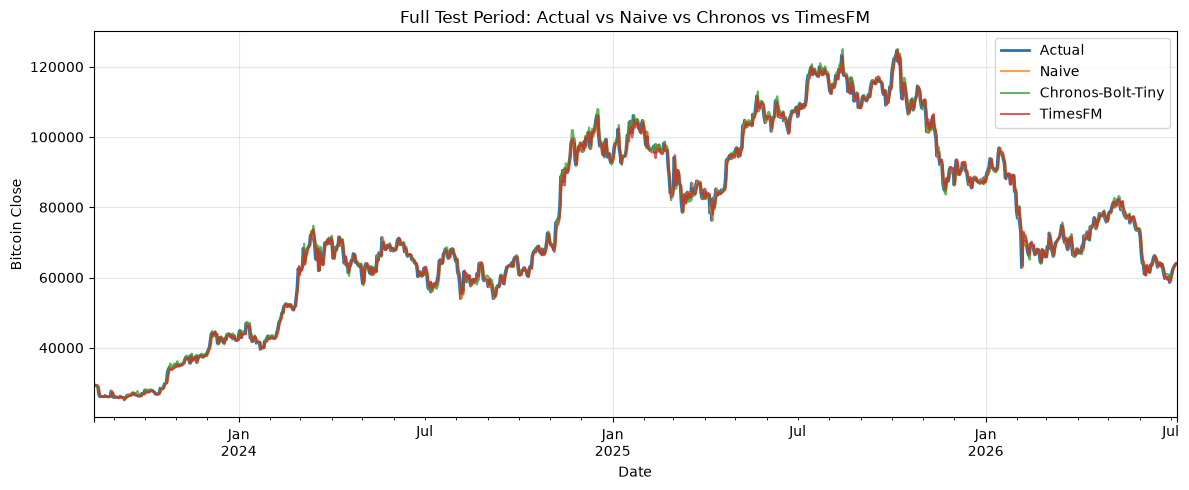

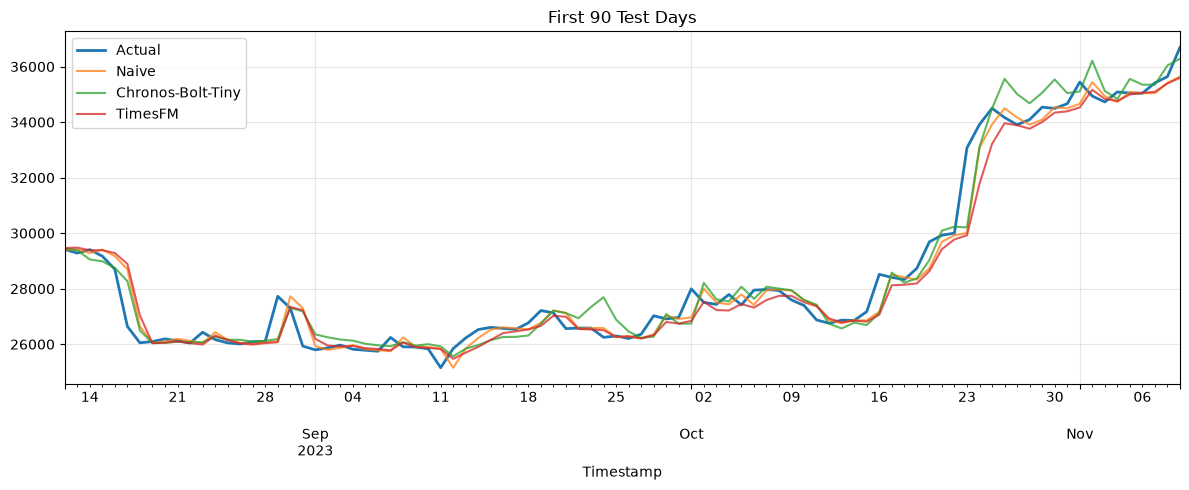

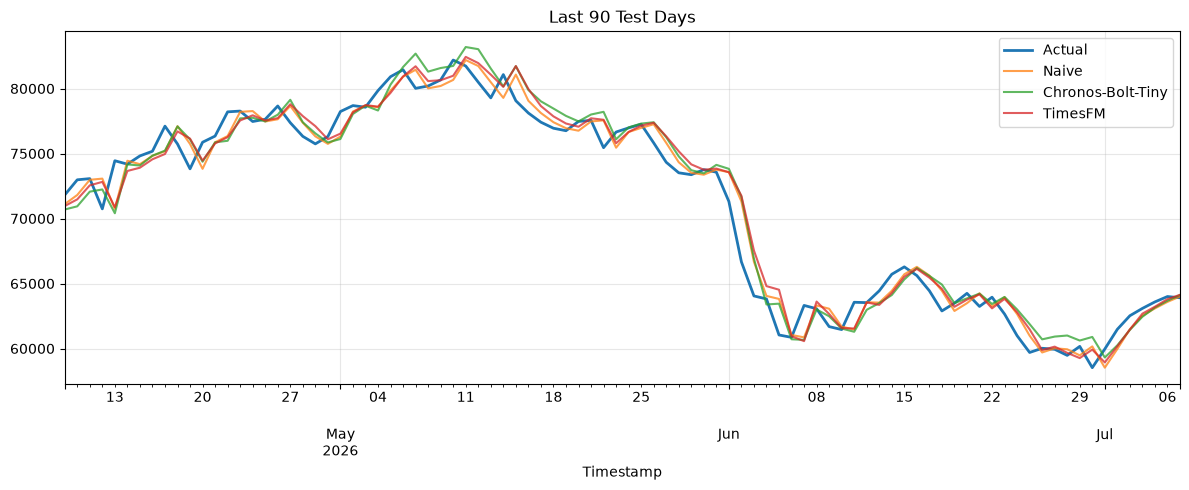

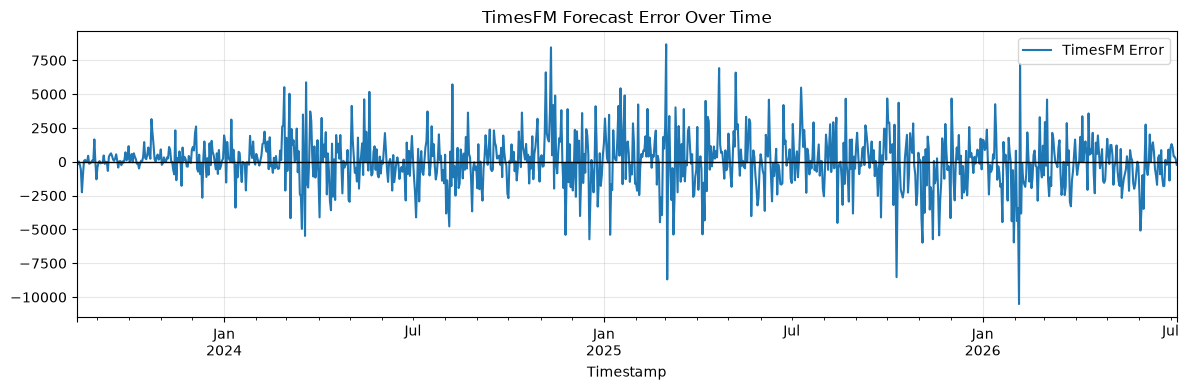

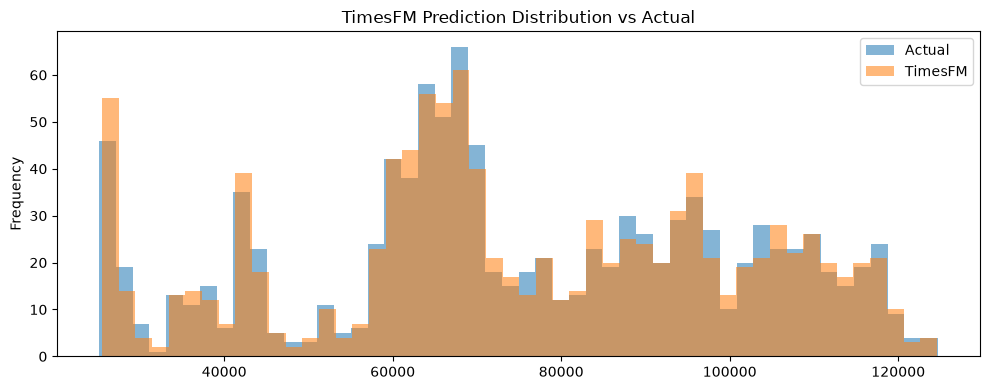

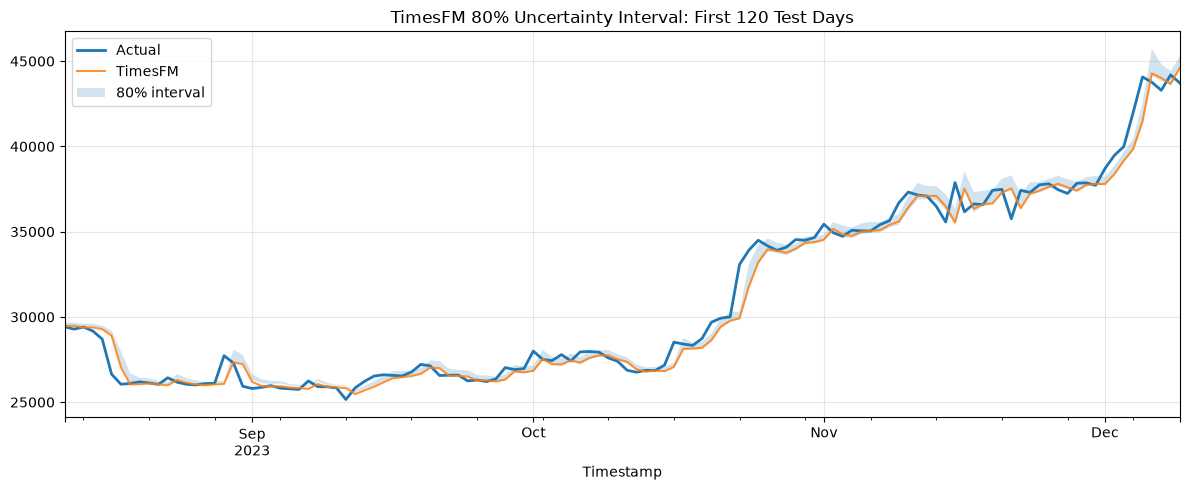

In [31]:
chronos_for_plot = pd.Series(
    validated_forecasts["Chronos_Bolt_Tiny"].to_numpy(dtype=float),
    index=y_test.index,
    name="Chronos-Bolt-Tiny",
)

fig, ax = plt.subplots(figsize=(12, 5))
y_test.plot(ax=ax, label="Actual", linewidth=2)
naive_forecast.plot(ax=ax, label="Naive", alpha=0.75)
chronos_for_plot.plot(ax=ax, label="Chronos-Bolt-Tiny", alpha=0.75)
timesfm_forecast.plot(ax=ax, label="TimesFM", alpha=0.75)
ax.set_title("Full Test Period: Actual vs Naive vs Chronos vs TimesFM")
ax.set_xlabel("Date")
ax.set_ylabel("Bitcoin Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
y_test.head(90).plot(ax=ax, label="Actual", linewidth=2)
naive_forecast.head(90).plot(ax=ax, label="Naive", alpha=0.75)
chronos_for_plot.head(90).plot(ax=ax, label="Chronos-Bolt-Tiny", alpha=0.75)
timesfm_forecast.head(90).plot(ax=ax, label="TimesFM", alpha=0.75)
ax.set_title("First 90 Test Days")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
y_test.tail(90).plot(ax=ax, label="Actual", linewidth=2)
naive_forecast.tail(90).plot(ax=ax, label="Naive", alpha=0.75)
chronos_for_plot.tail(90).plot(ax=ax, label="Chronos-Bolt-Tiny", alpha=0.75)
timesfm_forecast.tail(90).plot(ax=ax, label="TimesFM", alpha=0.75)
ax.set_title("Last 90 Test Days")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
timesfm_error.plot(ax=ax, label="TimesFM Error")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("TimesFM Forecast Error Over Time")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
y_test.plot(kind="hist", bins=50, alpha=0.55, ax=ax, label="Actual")
timesfm_forecast.plot(kind="hist", bins=50, alpha=0.55, ax=ax, label="TimesFM")
ax.set_title("TimesFM Prediction Distribution vs Actual")
ax.legend()
plt.tight_layout()
plt.show()

if timesfm_lower_80 is not None and timesfm_upper_80 is not None:
    subset_index = y_test.head(120).index
    fig, ax = plt.subplots(figsize=(12, 5))
    y_test.reindex(subset_index).plot(ax=ax, label="Actual", linewidth=2)
    timesfm_forecast.reindex(subset_index).plot(ax=ax, label="TimesFM", alpha=0.85)
    ax.fill_between(
        subset_index,
        timesfm_lower_80.reindex(subset_index).to_numpy(dtype=float),
        timesfm_upper_80.reindex(subset_index).to_numpy(dtype=float),
        alpha=0.2,
        label="80% interval",
    )
    ax.set_title("TimesFM 80% Uncertainty Interval: First 120 Test Days")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 8. Moirai

Moirai is evaluated here as a compatibility and smoke-test candidate only. The active environment is Python `3.13.2`, CPU-only PyTorch `2.12.1+cpu`.

Installation was attempted with the active project interpreter:

```powershell
.\.venv\Scripts\python.exe -m pip install uni2ts
```

The install did **not** complete. The official `uni2ts==2.0.0` package depends on `numpy~=1.26.0`. Under Python 3.13, pip attempted to build `numpy==1.26.4` from source because a compatible wheel was not available. That build failed because the local Windows environment does not have an MSVC compiler toolchain (`cl`, `clang-cl`, etc.).

Because Uni2TS did not install, no Moirai imports, model loading, or smoke-test forecasts are reported. No validated forecast artifacts are modified.


In [32]:
moirai_install_attempt = {
    "Model": "Moirai / Uni2TS",
    "Package Attempted": "uni2ts",
    "Install Command": r".\.venv\Scripts\python.exe -m pip install uni2ts",
    "Install Result": "Failed",
    "Installed Package Version": "Not installed",
    "Import Result": "Not attempted because installation failed",
    "Selected Model": "None",
    "Protocol Attempted": "Installation and compatibility check only",
    "Package Available": package_available("uni2ts"),
    "Runnable Now": False,
    "Exact Compatibility Blocker": (
        "uni2ts==2.0.0 requires numpy~=1.26.0; on Python 3.13 pip attempted to build "
        "numpy==1.26.4 from source and failed because no MSVC compiler was available."
    ),
    "Dependency Warning": "Moirai/Uni2TS remains better suited to a separate Python 3.11/3.12 environment with compatible pinned dependencies.",
    "pip check output after failed install": "No broken requirements found.",
}

pd.DataFrame([moirai_install_attempt])


,Model,Package Attempted,Install Command,Install Result,Installed Package Version,Import Result,Selected Model,Protocol Attempted,Package Available,Runnable Now,Exact Compatibility Blocker,Dependency Warning,pip check output after failed install
0,Moirai / Uni2TS,uni2ts,.\.venv\Scripts\python.exe -m pip install uni2ts,Failed,Not installed,Not attempted because installation failed,None,Installation and compatibility check only,False,False,uni2ts==2.0.0 requires numpy~=1.26.0; on Pytho...,Moirai/Uni2TS remains better suited to a separ...,No broken requirements found.


## 9. Forecast Diagnostics

In [33]:
diagnostic_rows = []
diagnostic_rows.append(forecast_diagnostics("Naive", naive_forecast, protocol="Rolling one-step"))
diagnostic_rows.append(forecast_diagnostics("7-Day Moving Average", moving_average_7, protocol="Rolling one-step"))

if chronos_forecast is not None:
    diagnostic_rows.append(
        forecast_diagnostics(
            "Chronos",
            chronos_forecast,
            inference_time_seconds=chronos_inference_time_seconds,
            protocol="Rolling one-step",
        )
    )
if timesfm_forecast is not None:
    diagnostic_rows.append(
        forecast_diagnostics(
            "TimesFM",
            timesfm_forecast,
            inference_time_seconds=timesfm_inference_time_seconds,
            protocol="Rolling one-step",
        )
    )

forecast_diagnostics_table = pd.DataFrame(diagnostic_rows).set_index("Model")
forecast_diagnostics_table


,Protocol,Forecast Length,Index Alignment,Missing Values,Constant Prediction,Prediction Min,Prediction Max,Prediction Mean,Prediction Std,Actual Std,Correlation,Daily Change Std Ratio,Inference Time Seconds
Model,,,,,,,,,,,,,
Naive,Rolling one-step,1061,True,0,False,25155.000000,124728.000000,75138.584628,25600.549440,25564.279690,0.997374,0.999998,NaN
7-Day Moving Average,Rolling one-step,1061,True,0,False,25796.285714,122775.857143,75043.435219,25635.732997,25564.279690,0.993145,0.359243,NaN
Chronos,Rolling one-step,1061,True,0,False,25564.470703,125071.718750,75360.976562,25667.591797,25564.279690,0.997003,0.986677,1.308986
TimesFM,Rolling one-step,1061,True,0,False,25473.763672,124593.343750,75127.860977,25571.139843,25564.279690,0.997167,0.940303,35.396255


## 10. Evaluation Metrics

In [34]:
foundation_metric_rows = []

if chronos_forecast is not None:
    foundation_metric_rows.append(metric_row("Chronos", chronos_forecast, protocol="Rolling one-step", status="Run"))
else:
    foundation_metric_rows.append(
        {
            "Model": "Chronos",
            "Protocol": "Rolling one-step target protocol",
            "Status": "Not run in current environment",
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE": np.nan,
            "sMAPE": np.nan,
        }
    )

if timesfm_forecast is not None:
    foundation_metric_rows.append(metric_row("TimesFM", timesfm_forecast, protocol="Rolling one-step", status="Run"))
else:
    foundation_metric_rows.append(
        {
            "Model": "TimesFM",
            "Protocol": "Rolling one-step target protocol",
            "Status": "Not run in current environment",
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE": np.nan,
            "sMAPE": np.nan,
        }
    )

foundation_metric_rows.append(
    {
        "Model": "Moirai",
        "Protocol": "Not attempted",
        "Status": "Not run in current environment",
        "MAE": np.nan,
        "RMSE": np.nan,
        "MAPE": np.nan,
        "sMAPE": np.nan,
    }
)

foundation_metrics = pd.DataFrame(foundation_metric_rows).set_index("Model")
foundation_metrics


,Protocol,Status,MAE,RMSE,MAPE,sMAPE
Model,,,,,,
Chronos,Rolling one-step,Run,1424.025828,1994.007926,1.934509,1.928782
TimesFM,Rolling one-step,Run,1349.946786,1924.199337,1.823179,1.823895
Moirai,Not attempted,Not run in current environment,NaN,NaN,NaN,NaN


## 11. Comparison with Existing Models

This table includes locally computed baselines and reserved rows for the project models requested for comparison. Rows with unavailable forecasts are explicitly marked as not loaded rather than populated with invented values. Collapsed or invalid Transformer forecasts are intentionally excluded from the main comparison.


In [35]:
comparison_rows = []
comparison_rows.extend(baseline_metrics.reset_index().to_dict("records"))
comparison_rows.extend(foundation_metrics.reset_index().to_dict("records"))

existing_model_placeholders = [
    "Original LSTM",
    "Persistence-Enhanced LSTM",
    "ARIMA(1,1,1)",
    "SARIMA",
]
for model_name in existing_model_placeholders:
    comparison_rows.append(
        {
            "Model": model_name,
            "Protocol": "Use audited protocol from prior notebook before direct comparison",
            "Status": "Forecast not loaded in this notebook",
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE": np.nan,
            "sMAPE": np.nan,
        }
    )

comparison_table = pd.DataFrame(comparison_rows)
comparison_table = comparison_table[
    ["Model", "Protocol", "Status", "MAE", "RMSE", "MAPE", "sMAPE"]
].sort_values("RMSE", na_position="last")
comparison_table


,Model,Protocol,Status,MAE,RMSE,MAPE,sMAPE
0,Naive,Rolling one-step,Run,1290.353242,1853.624774,1.742747,1.744142
3,TimesFM,Rolling one-step,Run,1349.946786,1924.199337,1.823179,1.823895
2,Chronos,Rolling one-step,Run,1424.025828,1994.007926,1.934509,1.928782
1,7-Day Moving Average,Rolling one-step,Run,2209.776153,2999.605073,3.021810,3.024208
4,Moirai,Not attempted,Not run in current environment,NaN,NaN,NaN,NaN
5,Original LSTM,Use audited protocol from prior notebook befor...,Forecast not loaded in this notebook,NaN,NaN,NaN,NaN
6,Persistence-Enhanced LSTM,Use audited protocol from prior notebook befor...,Forecast not loaded in this notebook,NaN,NaN,NaN,NaN
7,"ARIMA(1,1,1)",Use audited protocol from prior notebook befor...,Forecast not loaded in this notebook,NaN,NaN,NaN,NaN
8,SARIMA,Use audited protocol from prior notebook befor...,Forecast not loaded in this notebook,NaN,NaN,NaN,NaN


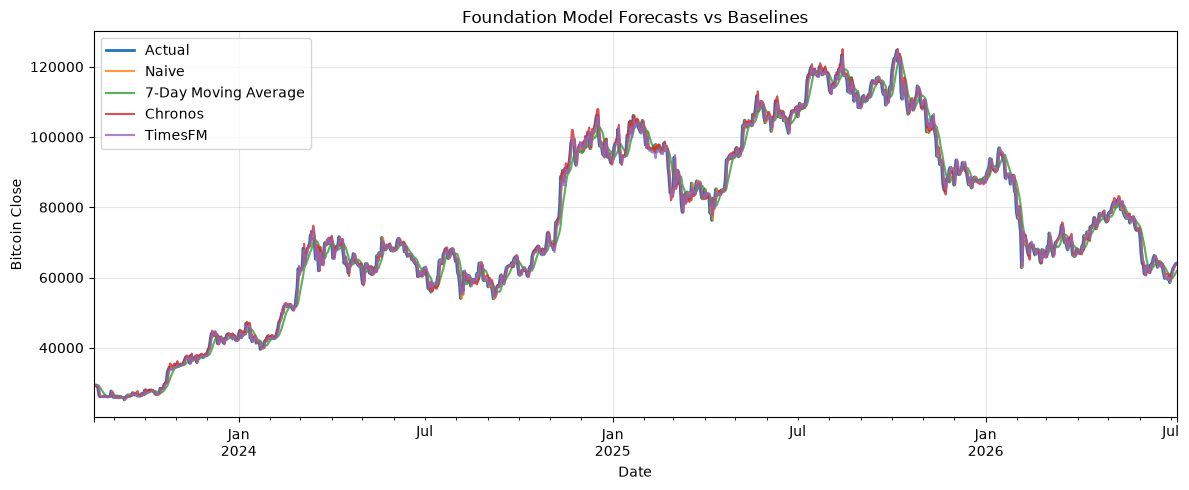

In [36]:
fig, ax = plt.subplots(figsize=(12, 5))
y_test.plot(ax=ax, label="Actual", linewidth=2)
naive_forecast.plot(ax=ax, label="Naive", alpha=0.8)
moving_average_7.plot(ax=ax, label="7-Day Moving Average", alpha=0.8)
if chronos_forecast is not None:
    chronos_forecast.plot(ax=ax, label="Chronos", alpha=0.8)
if timesfm_forecast is not None:
    timesfm_forecast.plot(ax=ax, label="TimesFM", alpha=0.8)
ax.set_title("Foundation Model Forecasts vs Baselines")
ax.set_xlabel("Date")
ax.set_ylabel("Bitcoin Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Key Findings

- The dataset and split are compatible with the rest of the project: the 80/20 split trains through `2023-08-11` and tests from `2023-08-12`.
- Chronos-Bolt-Tiny completed a full rolling one-step evaluation and produced the validated artifact used downstream.
- TimesFM installed successfully in the current Python 3.13.2 environment as `timesfm==2.0.2`; `pip check` reported no broken requirements.
- The full TimesFM rolling one-step evaluation completed all `1,061` forecasts on CPU using `google/timesfm-2.5-200m-pytorch`.
- TimesFM performed between Persistence-Enhanced LSTM and Chronos-Bolt-Tiny in this run, with RMSE higher than Naive but lower than Chronos.
- TimesFM preserved realistic price-scale variability, but its 80% interval coverage was low, so its native uncertainty interval should not be trusted without calibration.
- Moirai / Uni2TS was attempted with `pip install uni2ts`, but installation failed because `uni2ts==2.0.0` requires `numpy~=1.26.0`, which is not compatible as a prebuilt wheel with this Python 3.13 environment. Pip attempted a source build of NumPy and failed due to a missing MSVC compiler.
- No Moirai import, checkpoint load, or smoke-test forecast is reported.
- No foundation-model metrics are reported unless the corresponding model actually runs.
- Collapsed or invalid Transformer forecasts are excluded from the main comparison.


## 13. Limitations

- TimesFM has now been run as a full rolling one-step evaluation, but only with the 200M PyTorch model exposed by `timesfm==2.0.2`.
- The current environment is CPU-only and had limited available RAM during the run.
- TimesFM inference was batched through the model API, but full rolling evaluation is still heavier than Chronos-Bolt-Tiny.
- TimesFM 95% interval coverage is not reported because the installed package metadata exposes quantiles `0.1` through `0.9`, not `0.025` and `0.975`.
- Moirai/Uni2TS could not be installed in the current Python 3.13.2 environment. The exact blocker was the `numpy~=1.26.0` dependency, which triggered a failed source build of NumPy 1.26.4 due to a missing MSVC compiler. A separate Python 3.11 or 3.12 environment remains the clean path for Moirai.
